# 04-1. 피크 저감 시뮬레이션 — 생산 일정·설비 가동 시점 조정

과제의 세 번째 요구인 **"생산일정 또는 설비가동 시점 조정을 통한 피크전력 저감방안"**을 다룹니다. 보고서 **제4장 「현장 활용방안」**의 근거 자료입니다.

실제 공장의 운영을 바꿔 볼 수는 없으므로, **측정된 전력 기록에 '만약 이렇게 운영했다면'을 적용하는 시뮬레이션**으로 효과를 추정합니다.
설비별 전력 기록이 없어서 '옮길 수 있는 부하'는 도메인 조사(README의 참고문헌)를 바탕으로 **가정**합니다. 따라서 결과는 확정된 절감액이 아니라 **가정에 따른 추정 범위**입니다.

## 0. 준비

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

FIG_DIR = Path("../outputs/figures"); TAB_DIR = Path("../outputs/tables"); PRED_DIR = Path("../outputs/predictions")
def save_fig(fig, name): fig.savefig(FIG_DIR / f"{name}.png", dpi=200, bbox_inches="tight")
def save_table(df, name): df.to_csv(TAB_DIR / f"{name}.csv", encoding="utf-8-sig")

slots = pd.read_csv("../data/processed/slots_15min.csv", encoding="utf-8-sig", parse_dates=["ts", "date"], index_col="ts")
slots["칸번호"] = (slots["시각"] * 4).astype(int)
slots["하루종류코드"] = slots["하루종류"].map({"평일가동": 0, "토요일": 1, "휴일": 2})
CURVE_KEYS = ["하루종류코드", "전날가동", "칸번호"]
hour = pd.read_csv(PRED_DIR / "final_hour_ahead.csv", encoding="utf-8-sig", parse_dates=["발행시각", "대상시각"])

FIRST_TEST = pd.Timestamp("2021-08-09")
TARGET = slots[(slots.index < FIRST_TEST) & slots["정답사용"]]["전력"].max()      # 목표전력 (02-3 노트북과 같음)
L1 = 0.85 * TARGET
print(f"목표전력 {TARGET:.0f}, 1단계 기준 {L1:.1f} (목표의 85%)")

목표전력 222, 1단계 기준 188.7 (목표의 85%)


## 1. 가정과 계산 기준 (도메인 조사 근거)

**옮길 수 있는 부하** — 위험 시간대(평일 08:00~12:00, 13:00~16:00) 부하 중 일부(f)를 옮길 수 있다고 가정합니다.
| 대상 설비 | 옮기는 방법 | 근거 |
|---|---|---|
| 열처리로 승온 | 승온 시작을 08시 이전(야간 교대 후반)이나 17시 이후로 | 한 제조사의 피트형 로 사양에서 무부하 승온 시간 상한 1.2~2.5시간, 무부하 소비전력 5~14kW (실제 장입 공정의 전력은 별도 계측 필요) |
| 소재 절단 | 다음 날 분량을 저녁·야간 교대에 미리 자름 | 배치 작업이라 순서를 바꾸기 쉬움 |
| 공기압축기·공조 | 피크 15분 구간에만 출력을 낮추거나 돌아가며 잠깐 끔 | 압축공기는 일반 공장 전력의 약 10% (미국 에너지부 자료), 최대수요전력 제어장치의 대표적인 차단 대상 |
| CNC 가공·전조 | 옮기지 않음 (생산 흐름의 중심) | – |

- 기본값 **f = 10%**, 범위 **5~15%**. 설비별 실측 비중을 확인하지 못해 정한 **가정값**입니다.
- **옮긴 전력량은 같은 날 안에서 그대로 다시 씁니다**(하루 전력량 보존. 생산량·품질·납기가 유지되는지는 검증하지 않음).
- **받는 칸**: 같은 날 06~22시 중 위험 시간대가 아닌 칸. 단, 아래 칸은 받지 않습니다.
  - 16시대(16:00~16:45): 요금상 최대부하 시간이고 피크가 자주 나는 시각
  - 전날 쉰 날(월요일 등)의 06~08시: 야간 교대가 없어 작업자가 없는 시간
  - 점심(12:00~12:45)·저녁(17:00~17:15) 휴게시간: 평일 전력 곡선이 뚜렷이 떨어지는 시간(01-1 노트북 그림 5)으로, 작업자가 없어 설비를 새로 돌리기 어려움
- 받는 칸 중 18시 이후는 인건비가 1.5배인 시간입니다(데이터의 `인건비` 열). 이 시뮬레이션은 **기존 야간 교대 인원이 옮긴 작업을 맡는다**(추가 근무 없음)고 가정하며, 추가 근무가 필요하면 그만큼 절감액이 줄어듭니다.
- 받는 칸은 **하루 앞 예측 + 이미 받은 양**이 '1단계 − 10'(178.7)을 넘지 않는 만큼만 받습니다. 실제 전력이 아니라 예측으로 판단하므로, 실제로는 받는 칸이 1단계를 넘을 수도 있습니다(결과 표에 따로 셉니다).
- 기본 전력(약 22, 휴일 수준)은 옮길 수 없는 부분으로 봅니다.

**요금 계산** (2021년 한전 전기요금표, 산업용(을) 고압A **선택Ⅰ**)
- **계약 종류**: 데이터의 `전기요금(계절)` 값(191.6·109.8·167.2)이 산업용(을) 고압A 선택Ⅰ의 최대부하 단가와 정확히 같아(01-1 노트북 2-6), 선택Ⅰ을 **계산용 계약으로 가정**합니다. 실제 계약(종별·전압·선택요금·계약전력)은 고지서로 확인해야 합니다.
- **기본요금**: 7,220원/kW·월. 요금적용전력 = max(반영월의 중간·최대부하 시간대 15분 최대, 계약전력 × 30%)이므로, 계약전력의 30%가 203.5kW 이하라는 조건에서 **연 절감액 ≈ 줄어든 여름 최대(kW) × 7,220원 × 12개월**.
- **전력량요금**: 시간대마다 단가가 다릅니다(2021년 기준: 경부하 23~09시, 최대부하 10~12시·13~17시, 그 외 중간부하). 일요일·공휴일은 하루 종일 경부하, 토요일의 최대부하 시간은 중간부하로 계산합니다(전기공급약관 별표 3). 공휴일은 생산 휴무와 따로 정한 2021년 관공서 공휴일 달력입니다(8/16 대체공휴일은 공장이 가동했지만 요금상 공휴일). 여름(6~8월) 최대부하 → 경부하는 kWh당 135.0원, 최대 → 중간은 82.1원 쌉니다. 9월(봄·가을 단가)은 각각 53.2원, 30.7원입니다(선택Ⅰ·Ⅱ 같음).
- 비교를 위해 선택Ⅱ와 산업용(갑)Ⅱ(계약전력 300kW 미만일 때)의 결과도 함께 봅니다. 또한 이 공장의 사용 패턴에서는 **선택Ⅱ가 더 유리할 수 있어**, 요금제 변경 효과도 따로 계산합니다(3-2).

> **중요**: 7/19에 이미 222가 찍혔기 때문에, 2021년의 요금적용전력은 8~9월에 무엇을 하든 222 이상입니다. 그래서 요금 효과는 **'이 운영 방식을 여름 전체(7월 포함)에 적용했다면'**으로 계산합니다.

In [2]:
BASE = 22
# 2021년 한전 요금표 (원/kW·월, 원/kWh: 경부하·중간·최대). 출처: 2021.1.1 시행 전기요금표 (한국물가정보 공공요금)
TARIFF = {
    "산업용(을) 고압A 선택Ⅰ (기본, 데이터로 확인)": {"기본": 7220, "여름": (56.6, 109.5, 191.6), "봄가을": (56.6, 79.1, 109.8)},
    "산업용(을) 고압A 선택Ⅱ": {"기본": 8320, "여름": (51.1, 104.0, 186.1), "봄가을": (51.1, 73.6, 104.3)},
    "산업용(갑)Ⅱ 고압A 선택Ⅱ": {"기본": 7470, "여름": (50.6, 76.4, 109.9), "봄가을": (50.6, 55.4, 74.6)},
}
# 2021년 관공서 공휴일(자료 기간). 생산 휴무(하루종류)와는 다른, 요금 계산 전용 달력. 8/16은 공장이 가동했지만 요금상 공휴일
HOLIDAYS_2021 = set(pd.to_datetime(["2021-01-01", "2021-02-11", "2021-02-12", "2021-02-13", "2021-03-01", "2021-05-05",
                                    "2021-05-19", "2021-06-06", "2021-08-15", "2021-08-16"]))
def rate_holiday(ts): return ts.weekday() == 6 or ts.normalize() in HOLIDAYS_2021
def tou_band(ts):
    """2021년 시간대(전기공급약관 별표 3): 일요일·공휴일은 하루 종일 경부하, 토요일의 최대부하 시간은 중간부하"""
    h = ts.hour
    if rate_holiday(ts) or h >= 23 or h < 9: return 0      # 경부하
    if (10 <= h < 12) or (13 <= h < 17): return 1 if ts.weekday() == 5 else 2   # 최대부하 (토요일은 중간)
    return 1                                                # 중간부하
slots["요금시간대"] = [["경부하", "중간부하", "최대부하"][tou_band(t)] for t in slots.index]
slots["요금대상"] = slots["요금시간대"] != "경부하"     # 기본요금 대상 최대수요: 중간·최대부하 시간대(공휴일·경부하 제외)
def unit_price(ts, tariff):
    season = "여름" if ts.month in (6, 7, 8) else "봄가을"
    return TARIFF[tariff][season][tou_band(ts)]
BASE_TARIFF = "산업용(을) 고압A 선택Ⅰ (기본, 데이터로 확인)"
for name in TARIFF:
    slots["단가_" + name] = [unit_price(t, name) for t in slots.index]
print(slots.groupby(slots.index.hour)["요금시간대"].first().to_dict())

{0: '경부하', 1: '경부하', 2: '경부하', 3: '경부하', 4: '경부하', 5: '경부하', 6: '경부하', 7: '경부하', 8: '경부하', 9: '중간부하', 10: '최대부하', 11: '최대부하', 12: '중간부하', 13: '최대부하', 14: '최대부하', 15: '최대부하', 16: '최대부하', 17: '중간부하', 18: '중간부하', 19: '중간부하', 20: '중간부하', 21: '중간부하', 22: '중간부하', 23: '경부하'}


### 1-1. 옮길 수 있는 부하는 데이터로 보면 얼마나 되나
위의 f = 10%(5~15%)는 도메인 조사로 정한 **가정값**입니다. 설비별 계측이 없으므로 정답을 알 수는 없지만, 15분 전력만으로도 **"시간대·날에 따라 달라지는 부하가 대략 얼마인가"**는 볼 수 있습니다. 여기서는 이 값과 가정을 비교해 **점검만** 하고, 뒤의 시뮬레이션(f = 5·10·15%)은 그대로 둡니다.

**기준(분모)**: 시뮬레이션의 f와 똑같이 **'위험 시간대 부하 − 기본 전력(22)'**에 대한 비율로 나타냅니다. 위험 시간대 부하는 평일 가동일 08:00~12:00, 13:00~16:00의 평균이며, 가동 시작(08:00·08:15)과 휴게 전후 칸(10:00·10:15, 12시대, 13:00·13:15, 15:00·15:15)은 정해진 전환이라 뺍니다.

| 방법 | 무엇을 보나 | 성격 |
|---|---|---|
| (a) 부하 구성 분해 | 위험 시간대에만 더해지는 부하 = 위험 시간대 − 가동 중 다른 시간대(야간 01~05시, 저녁 18~20시) | **상한**: 주간에만 도는 설비 전체(옮기기 어려운 생산 설비 포함) |
| (b) 계단형 변화 | 정상 운전 중 15분 사이 ±15kW 이상 바뀌는 크기 = 켜고 끄는 큰 설비 한 덩어리 | **참고**: 설비 한 대(블록)의 크기 |
| (b′) 휴게시간 하락 | 15분 휴게(10:00·15:00)에 떨어지는 폭 = 사람이 잠깐 멈출 수 있는 부하 | **상한 쪽 참고**: 생산 설비 포함, 옮기면 생산 손실 |
| (c) 날 사이 변동 | 같은 시각의 날마다 다른 폭(분위수 차이), 하루 최대가 그날 평소보다 튀는 폭 | **참고**: 운영에 따라 달라지는 부분 |
| (d) 문헌 대조 | 압축공기 약 10%(미국 에너지부), 배치형 열처리로 정격 25~75kW(제조사 사양) | **하한·참고** |

In [3]:
# 1-1. 옮길 수 있는 부하 점검 (설비별 계측 없음 → 15분 전력만으로 하는 가벼운 추정)
def shiftable_check():
    o = slots[slots["정답사용"] & slots["전력"].notna() & (slots["하루종류"] == "평일가동")].copy()
    h, hm = o.index.hour, o.index.hour * 100 + o.index.minute
    o["hm"] = hm
    risk = ((h >= 8) & (h < 12)) | ((h >= 13) & (h < 16))
    trans = np.isin(hm, [800, 815, 1000, 1015, 1200, 1215, 1230, 1245, 1300, 1315, 1500, 1515])   # 가동 시작·휴게 전후
    steady = risk & ~trans
    p_risk = o.loc[steady, "전력"].mean()
    den = p_risk - BASE                                                    # f와 같은 기준
    p_night = o.loc[o["전날가동"] & (h >= 1) & (h < 5), "전력"].mean()    # 야간 정상 운전
    p_eve = o.loc[(h >= 18) & (h < 20), "전력"].mean()                     # 저녁 연장 운전
    # (b) 같은 날 안에서 15분 사이 변화 (정상 운전 칸만)
    d = o["전력"].diff().where(o["date"].eq(o["date"].shift()))
    dd = d[steady & d.notna()].abs()
    n_days = o.loc[steady, "date"].nunique()
    big15, big20 = dd[dd >= 15], dd[dd >= 20]
    prof = o.groupby("hm")["전력"].mean()
    brk = np.mean([prof[945] - prof[1000], prof[1445] - prof[1500]])      # 15분 휴게 하락
    # (c) 날 사이 변동 (전날 가동한 평일, 정상 운전 칸)
    pv = o[steady & o["전날가동"]].pivot_table(index="date", columns="hm", values="전력")
    iqr = (pv.quantile(0.75) - pv.quantile(0.25)).median()
    dm = o[risk].groupby("date")["전력"].agg(["max", "median"])
    spike = (dm["max"] - dm["median"]).median()
    # (d) 문헌: 압축공기 = 공장 전력의 약 10% → 가동일 평균 전력의 10%
    comp = 0.10 * o["전력"].mean()
    pct = lambda kw: f"{kw / den * 100:.0f}%"
    rows = [
        ["(a) 구성 분해: 위험 시간대 − 야간(01~05시)", f"{p_risk - p_night:.0f}", pct(p_risk - p_night), "상한",
         f"주간에만 더해지는 부하 전체. CNC·전조 등 주간 생산 설비가 대부분이라 그대로 옮길 수는 없음 (위험 {p_risk:.0f}, 야간 {p_night:.0f})"],
        ["(a) 구성 분해: 위험 시간대 − 저녁 연장(18~20시)", f"{p_risk - p_eve:.0f}", pct(p_risk - p_eve), "현실적 상한",
         f"생산은 하지만 주간 피크 시간대에만 붙는 부하 (저녁 {p_eve:.0f}). 시간대에 따라 달라지는 부하의 크기"],
        ["(b) 계단형 변화: 15분 사이 ±15kW 이상", f"{big15.median():.0f}", pct(big15.median()), "참고(블록 크기)",
         f"켜고 끄는 큰 설비 한 덩어리. 정상 운전 중 하루 {len(big15) / n_days:.1f}회 (±20kW 이상은 하루 {len(big20) / n_days:.1f}회, 중앙 {big20.median():.0f}kW)"],
        ["(b′) 15분 휴게(10:00·15:00) 하락", f"{brk:.0f}", pct(brk), "상한 쪽 참고",
         "사람이 15분 멈출 수 있는 부하. 생산 설비가 포함되어, 옮기면 생산이 줄어듦"],
        ["(c) 날 사이 변동: 같은 시각 사분위 범위(중앙)", f"{iqr:.0f}", pct(iqr), "참고",
         "같은 평일·같은 시각인데 날마다 달라지는 폭 → 운영(작업 배치)에 따라 달라지는 부분"],
        ["(c) 하루 최대 − 그날 위험 시간대 중앙값", f"{spike:.0f}", pct(spike), "참고",
         "평소 수준 위로 튀는 피크의 크기. 이만큼 옮기면 그날 피크가 평소 수준으로 내려감"],
        ["(d) 문헌: 압축공기 ≈ 공장 전력의 10%", f"{comp:.0f}", pct(comp), "하한 쪽 참고",
         "가동일 평균 전력의 10%. 감발·순차 정지로 일부만 줄일 수 있음"],
        ["(d) 문헌: 배치형 열처리로 1대 정격(승온 1.2~2.5시간)", "25~75", f"{25 / den * 100:.0f}~{75 / den * 100:.0f}%", "참고(불확실)",
         "승온이 위험 시간대에 걸릴 때만 해당. 이 공장 로의 종류·크기는 확인 못 함"],
        ["가정: f = 5% / 10% / 15%", f"{0.05 * den:.0f} / {0.10 * den:.0f} / {0.15 * den:.0f}", "5% / 10% / 15%", "시뮬레이션 가정",
         "위험 시간대 평균 부하 기준으로 환산한 kW"],
    ]
    tab = pd.DataFrame(rows, columns=["방법", "추정(kW)", "위험 시간대 부하 대비(기본 전력 제외)", "성격", "해석"]).set_index("방법")
    print(f"위험 시간대 정상 운전 평균 {p_risk:.1f}kW, 기본 전력 {BASE} → 분모 {den:.1f}kW")
    return tab

t43 = shiftable_check()
save_table(t43, "t43_옮길수있는부하_추정")
t43

위험 시간대 정상 운전 평균 180.0kW, 기본 전력 22 → 분모 158.0kW


,추정(kW),위험 시간대 부하 대비(기본 전력 제외),성격,해석
방법,,,,
(a) 구성 분해: 위험 시간대 − 야간(01~05시),75,47%,상한,주간에만 더해지는 부하 전체. CNC·전조 등 주간 생산 설비가 대부분이라 그대로 ...
(a) 구성 분해: 위험 시간대 − 저녁 연장(18~20시),28,18%,현실적 상한,생산은 하지만 주간 피크 시간대에만 붙는 부하 (저녁 152). 시간대에 따라 달라...
(b) 계단형 변화: 15분 사이 ±15kW 이상,18,11%,참고(블록 크기),켜고 끄는 큰 설비 한 덩어리. 정상 운전 중 하루 3.2회 (±20kW 이상은 하...
(b′) 15분 휴게(10:00·15:00) 하락,34,22%,상한 쪽 참고,"사람이 15분 멈출 수 있는 부하. 생산 설비가 포함되어, 옮기면 생산이 줄어듦"
(c) 날 사이 변동: 같은 시각 사분위 범위(중앙),17,11%,참고,같은 평일·같은 시각인데 날마다 달라지는 폭 → 운영(작업 배치)에 따라 달라지는 부분
(c) 하루 최대 − 그날 위험 시간대 중앙값,18,11%,참고,평소 수준 위로 튀는 피크의 크기. 이만큼 옮기면 그날 피크가 평소 수준으로 내려감
(d) 문헌: 압축공기 ≈ 공장 전력의 10%,13,8%,하한 쪽 참고,가동일 평균 전력의 10%. 감발·순차 정지로 일부만 줄일 수 있음
(d) 문헌: 배치형 열처리로 1대 정격(승온 1.2~2.5시간),25~75,16~47%,참고(불확실),승온이 위험 시간대에 걸릴 때만 해당. 이 공장 로의 종류·크기는 확인 못 함
가정: f = 5% / 10% / 15%,8 / 16 / 24,5% / 10% / 15%,시뮬레이션 가정,위험 시간대 평균 부하 기준으로 환산한 kW


**해석** — 표 43
- **가동 중이어도 주간에만 더해지는 부하는 약 47%(야간 대비)**입니다. 하지만 대부분 CNC·전조처럼 사람과 공정에 묶인 생산 설비라 그대로 옮길 수 없습니다. 이 값은 '옮길 수 있는 부하'의 넉넉한 **상한**입니다.
- 생산을 계속하는 **저녁 연장 운전(18~20시)과 비교하면, 주간 피크 시간대에만 붙는 부하는 약 18%**입니다. 시간대에 따라 켜지고 꺼지는 부하의 **현실적인 상한**으로 봅니다.
- **설비 한 덩어리(15분 사이 ±15kW 이상 변화)의 크기는 중앙 약 18kW(11%)**이고, 같은 시각의 **날 사이 변동(사분위 범위)도 약 11%**, **하루 최대가 그날 평소보다 튀는 폭도 약 11%**입니다. 세 값이 모두 11% 안팎에 모입니다. '설비 한두 대를 언제 켜느냐'가 만드는 변동이 이 정도라는 뜻입니다.
- 15분 휴게에 떨어지는 폭은 약 22%로 더 크지만, 생산 설비가 함께 멈추는 것이라 옮길 수 있는 부하로 보기는 어렵습니다(상한 쪽 참고).
- 문헌의 압축공기 비중(공장 전력의 약 10%)을 이 공장 가동일 평균 전력에 대 보면 약 13kW(8%)이고, 감발로 그중 일부만 줄일 수 있습니다. **하한 쪽 근거**입니다.

**결론**: 데이터에서 '시간대·날에 따라 달라지는 부하'는 **약 11~18%**(현실적 범위), 넓게 잡은 상한은 약 47%입니다. f = 10%는 이 범위 안에 들어가고 설비 한 대 크기(약 18kW)와도 비슷합니다. 다만 이 점검은 10%가 **'달라지는 부하의 크기 안에 들어가는지'만** 본 것이며, 실제로 옮길 수 있는 양의 하한이나 보수성을 입증하지는 않습니다. 가정값은 바꾸지 않습니다.

**한계**
- 설비별 계측이 없어 **'달라지는 부하'가 곧 '옮길 수 있는 부하'는 아닙니다.** 달라지는 이유가 작업 배치(옮길 수 있음)인지, 생산량·제품 차이(옮길 수 없음)인지 구분하지 못합니다.
- 저녁 연장 운전에도 배치 설비가 일부 돌 수 있어, 18%가 과소일 수도 있습니다. 반대로 야간 대비 47%에는 생산 설비가 많이 섞여 있어 과대입니다.
- 열처리로가 전기로인지, 몇 kW인지 확인하지 못했습니다. 실제 적용 전에는 주요 설비 몇 대에 간이 전력계를 달아 1~2주 측정하면 f를 바로 확인할 수 있습니다.

## 2. 시나리오

| 시나리오 | 언제 결정하나 | 무엇을 하나 | 적용 기간 |
|---|---|---|---|
| **A1. 고정 규칙형** | 미리 정한 운영 규칙 | 매 가동일 위험 시간대(08:00~12:00, 13:00~16:00)에는 옮길 수 있는 설비를 돌리지 않고, 같은 날 위험 시간대 밖(06~22시)의 여유 있는 칸으로 옮김 | 7/12 ~ 9/14 |
| **A2. 예측 기반형** | 전날 저녁 (하루 앞 예측) | 위 규칙을 예측상 위험한 칸(위험 시간대에서 예측이 '1단계 − 10' 이상)에만 적용 | 7/12 ~ 9/14 (그날 이전 데이터로 기준 곡선을 만들 수 있는 날부터) |
| **B. 경보 대응형** | 당일 (1시간 앞 경보) | 경보가 울린 칸의 옮길 수 있는 부하를 같은 날 45분 이후의 경보 없는 여유 칸으로 미룸 | 8/16 ~ 9/14 (1시간 앞 최종 모델 예측이 있는 2~5주차) |
| **C. 순차 기동** | 전날 (고정 규칙) | 08시대(08:00~08:45)에 함께 켜지는 설비 일부를 07시대로 앞당겨 나눠 켬 | 7/12 ~ 9/14 |

모든 시나리오는 **가동일**에만 적용하고, 하루 전력량은 바꾸지 않습니다. 받는 칸은 '예측 + 이미 받은 양'이 '1단계 − 10'을 넘지 않는 범위에서만 받습니다.

In [4]:
work = slots[(slots["하루종류"] == "평일가동") & (slots.index >= "2021-07-12")].copy()
ok = work["전력"].notna()                     # 계획(옮길 양·받는 칸)에 쓰는 칸: 기록이 있는 칸
ev = work["정답사용"].astype(bool)             # 효과 평가에 쓰는 칸: 정답 기준과 같음(7/28·7/30, 계측 중단 칸 제외)

# 하루 앞 예측(기준 곡선): 그날 이전 데이터로 만든 곡선
pred = pd.Series(np.nan, index=work.index)
for d in work["date"].unique():
    hist = slots[(slots.index < d) & slots["정답사용"]]
    curve = hist.groupby(CURVE_KEYS)["전력"].mean().rename("c")
    idx = work.index[work["date"] == d]
    pred.loc[idx] = work.loc[idx].join(curve, on=CURVE_KEYS)["c"].values
work["예측"] = pred
RISK = lambda h: ((h >= 8) & (h < 12)) | ((h >= 13) & (h < 16))
def receivers(g, after=None):
    """받는 칸: 06~22시, 위험 시간대·16시대·점심(12:00~12:45)·저녁(17:00~17:15) 휴게 제외, 전날 쉰 날은 06~08시 제외"""
    h = g.index.hour; mi = g.index.minute
    rest_break = (h == 12) | ((h == 17) & (mi < 30))
    m = (h >= 6) & (h < 22) & ~RISK(h) & (h != 16) & ~rest_break
    if not bool(g["전날가동"].iloc[0]):
        m &= h >= 8
    if after is not None:
        m &= g.index > after
    return list(g.index[m])
CAP = L1 - 10      # 받는 칸이 넘지 않아야 할 예측 수준 (경보 여유값과 같은 10)

def receive(out, cand, amount, added):
    """받는 칸: (기준 − 예측 − 이미 받은 양)의 여유 안에서만 받음"""
    cand = [c for c in cand if ok.loc[c]]
    head = (CAP - work.loc[cand, "예측"] - added.loc[cand]).clip(lower=0)
    room = head.sum(); take = min(amount, room)
    if room > 0:
        share = take * head / room
        out.loc[cand] += share; added.loc[cand] += share
    return take

def scenario_A(f, mode="고정", margin=10, return_added=False):
    """고정: 매 가동일 위험 시간대 전체에서 옮김 / 예측: 예측이 기준 근처인 칸에서만 옮김"""
    out = work["전력"].copy(); added = pd.Series(0.0, index=work.index)
    for d, g in work.groupby("date"):
        risky = RISK(g.index.hour) if mode == "고정" else RISK(g.index.hour) & (g["예측"] >= L1 - margin)
        donors = g.index[risky & ok.loc[g.index]]
        amt = (g.loc[donors, "전력"] - BASE).clip(lower=0) * f
        if amt.sum() == 0: continue
        took = receive(out, receivers(g), amt.sum(), added)
        out.loc[donors] -= amt * took / amt.sum()
    return (out, added) if return_added else out

def scenario_B(f, margin=10):
    out = work["전력"].copy(); added = pd.Series(0.0, index=work.index)
    al = hour[hour["1시간앞_예측"] >= L1 - margin]["대상시각"]
    alarm_set = set(al[al.isin(work.index)])
    for t in sorted(alarm_set):
        if not ok.loc[t]: continue
        amt = max(out.loc[t] - BASE, 0) * f
        g = work[work["date"] == t.normalize()]
        later = [x for x in receivers(g, after=t + pd.Timedelta(minutes=45)) if x not in alarm_set]
        out.loc[t] -= receive(out, later, amt, added)
    return out, len(alarm_set)

def scenario_C(f):
    out = work["전력"].copy()
    for d, g in work.groupby("date"):
        donors = g.index[(g.index.hour == 8) & ok.loc[g.index]]
        recv = [x for x in g.index[g.index.hour == 7] if ok.loc[x]]
        if not recv: continue
        amt = (g.loc[donors, "전력"] - BASE).clip(lower=0) * f
        out.loc[recv] += amt.sum() / len(recv)
        out.loc[donors] -= amt
    return out
print("시뮬레이션 대상 가동일:", work["date"].nunique(), "일")

시뮬레이션 대상 가동일: 42 일


## 3. 결과
각 시나리오의 효과를 **여름 최대수요전력(요금 기준)**, **1단계 초과 칸 수**, **하루 최대 평균**, **요금**으로 봅니다.

In [5]:
def summarize(name, new, mask, f):
    mask = np.asarray(mask) & ev.values          # 효과는 정답사용 칸에서만 평가
    a, b = work.loc[mask, "전력"], new[mask]
    da = a.groupby(work.loc[mask, "date"]).max(); db = b.groupby(work.loc[mask, "date"]).max()
    moved = (a - b).clip(lower=0).sum() * 0.25          # kWh (15분 = 0.25시간)
    energy_cost = ((b - a) * 0.25 * work.loc[mask, "단가_" + BASE_TARIFF]).sum()
    new_over = int(((b >= L1) & (a < L1)).sum())
    return {"시나리오": name, "옮긴 비율 f": f, "최대수요전력": a.max(), "조정 후 최대수요전력": round(b.max(), 1),
            "줄어든 최대(kW)": round(a.max() - b.max(), 1), "1단계 초과 칸": int((a >= L1).sum()), "조정 후 1단계 초과 칸": int((b >= L1).sum()), "그중 새로 넘은 칸(받는 칸)": new_over,
            "조정 후 최대가 나온 칸": b.idxmax().strftime("%m/%d %H:%M"),
            "받은 전력 중 18시 이후 비율": round(((b - a).clip(lower=0)[b.index.hour >= 18]).sum() / max((b - a).clip(lower=0).sum(), 1e-9), 2),
            "하루 최대 평균": round(da.mean(), 1), "조정 후 하루 최대 평균": round(db.mean(), 1),
            "옮긴 전력량(kWh)": round(moved), "전력량요금 변화(원)": round(energy_cost), "하루 전력량 차이": round(abs(a.sum() - b.sum()), 3)}

whole = work.index >= "2021-07-12"
test_b = work.index >= "2021-08-16"
rows, sims = [], {}
for f in [0.05, 0.10, 0.15]:
    sims[("A", f)] = scenario_A(f, "고정"); rows.append(summarize("A1. 고정 규칙형 (7/12~9/14)", sims[("A", f)], whole, f))
    sims[("A2", f)] = scenario_A(f, "예측"); rows.append(summarize("A2. 예측 기반형 (7/12~9/14)", sims[("A2", f)], whole, f))
    sims[("C", f)] = scenario_C(f); rows.append(summarize("C. 순차 기동 (7/12~9/14)", sims[("C", f)], whole, f))
    sims[("B", f)], n_alarm = scenario_B(f); rows.append(summarize("B. 경보 대응형 (8/16~9/14)", sims[("B", f)], test_b, f))
    rows.append(summarize("참고: A1을 B와 같은 기간에", sims[("A", f)], test_b, f))
res = pd.DataFrame(rows).set_index(["시나리오", "옮긴 비율 f"]).sort_index()
assert (res["하루 전력량 차이"] < 1e-6).all()
save_table(res.drop(columns="하루 전력량 차이"), "t29_피크저감_시나리오")
print("B 시나리오의 경보 칸 수:", n_alarm)
res.drop(columns="하루 전력량 차이")

B 시나리오의 경보 칸 수: 361


최대수요전력  조정 후 최대수요전력  줄어든 최대(kW)  1단계 초과 칸  \
시나리오                   옮긴 비율 f                                              
A1. 고정 규칙형 (7/12~9/14) 0.05      222.0        212.0        10.0       248   
                       0.10      222.0        203.5        18.5       248   
                       0.15      222.0        210.3        11.7       248   
A2. 예측 기반형 (7/12~9/14) 0.05      222.0        222.0         0.0       248   
                       0.10      222.0        222.0         0.0       248   
                       0.15      222.0        222.0         0.0       248   
B. 경보 대응형 (8/16~9/14)  0.05      204.0        198.0         6.0        60   
                       0.10      204.0        198.0         6.0        60   
                       0.15      204.0        198.0         6.0        60   
C. 순차 기동 (7/12~9/14)   0.05      222.0        222.0         0.0       248   
                       0.10      222.0        222.0         0.0       248   
                       0.15      222.0        222.0         0.0       248   
참고: A1을 B와 같은 기간에      0.05      204.0        194.9         9.1        60   
                       0.10      204.0        193.5        10.5        60   
                       0.15      204.0        200.8         3.2        60   

                                조정 후 1단계 초과 칸  그중 새로 넘은 칸(받는 칸) 조정 후 최대가 나온 칸  \
시나리오                   옮긴 비율 f                                                  
A1. 고정 규칙형 (7/12~9/14) 0.05                92                 2   07/19 11:15   
                       0.10                35                13   07/19 17:45   
                       0.15                44                34   07/19 17:45   
A2. 예측 기반형 (7/12~9/14) 0.05               124                 1   07/19 11:15   
                       0.10                72                 5   07/19 11:15   
                       0.15                66                10   07/19 11:15   
B. 경보 대응형 (8/16~9/14)  0.05                19                 0   09/01 08:45   
                       0.10                14                 0   09/01 08:45   
                       0.15                17                 3   09/01 08:45   
C. 순차 기동 (7/12~9/14)   0.05               219                 0   07/19 11:15   
                       0.10               203                 0   07/19 11:15   
                       0.15               197                 1   07/19 11:15   
참고: A1을 B와 같은 기간에      0.05                 9                 0   09/10 09:45   
                       0.10                 4                 3   08/23 18:00   
                       0.15                12                11   08/23 18:00   

                                받은 전력 중 18시 이후 비율  하루 최대 평균  조정 후 하루 최대 평균  \
시나리오                   옮긴 비율 f                                               
A1. 고정 규칙형 (7/12~9/14) 0.05                  0.64     198.1          190.1   
                       0.10                  0.64     198.1          185.9   
                       0.15                  0.64     198.1          187.6   
A2. 예측 기반형 (7/12~9/14) 0.05                  0.62     198.1          192.6   
                       0.10                  0.62     198.1          190.1   
                       0.15                  0.62     198.1          190.5   
B. 경보 대응형 (8/16~9/14)  0.05                  0.94     191.3          188.6   
                       0.10                  0.94     191.3          188.1   
                       0.15                  0.94     191.3          188.2   
C. 순차 기동 (7/12~9/14)   0.05                  0.00     198.1          196.4   
                       0.10                  0.00     198.1          196.1   
                       0.15                  0.00     198.1          196.1   
참고: A1을 B와 같은 기간에      0.05                  0.63     191.3          183.7   
                       0.10                  0.63     191.3          180.7   
                       0.15                  0.63     191.3          182.8   

                 

**해석** (효과는 정답사용 칸으로 평가: 정답에서 뺀 7/28·7/30과 계측 중단 칸은 계획에는 쓰지만 평가에서는 뺌)
- **A1. 고정 규칙형**: 위험 시간대 부하의 10%를 옮기면 여름 최대수요전력이 **222에서 203.5로 18.5kW** 줄어듭니다.
  - 위험 시간대 쪽 최대는 222 − 0.1 × (222 − 22) = 202로 산술적으로 정해집니다. 그런데 조정 후 최대(203.5)는 **받는 칸인 7/19 17:45**에서 나옵니다. 7/19는 월요일이라 06~08시에 받을 수 없고, 점심·저녁 휴게시간도 받지 않으므로, 옮긴 부하가 저녁 휴게 직후(17:30~18:00)에 몰렸습니다.
  - 1단계 초과 칸은 248개에서 35개로 줄어듭니다. 그중 13칸은 받는 칸이 새로 1단계를 넘은 경우입니다. 받는 칸의 여유를 실제가 아니라 하루 앞 예측으로 판단하기 때문입니다.
  - 옮긴 비율을 5%로 줄이면 212.0, 15%로 늘리면 210.3입니다(그림 22 나). **효과는 10% 안팎에서 가장 크고, 더 옮기면 받는 칸이 새 피크가 되어 오히려 나빠집니다.** 즉 이 공장에서 일정 조정의 한계를 정하는 것은 '얼마나 뺄 수 있나'보다 **'어디에 받을 수 있나'**입니다.
  - 받은 전력의 64%가 18시 이후에 들어갑니다. 인건비 할증(1.5배) 시간이므로, 기존 야간 교대 인원이 맡는다는 조건이 필요합니다.
- **A2. 예측 기반형**은 여유값 10 기준에서 여름 최대를 줄이지 못했습니다(222 그대로). 아래 3-1에서 보듯 이것은 기준값에 걸린 결과입니다.
- **B. 경보 대응형**: 2~5주차 최대를 204에서 198로 줄였습니다(f와 관계없이 6kW). 남은 최대(9/01 08:45)는 **경보가 울리지 않은 칸**입니다. 실시간 대응의 효과는 '경보가 놓친 피크'만큼 한계가 있습니다.
- **C. 순차 기동**은 여름 최대를 줄이지 못합니다(최대가 08시대가 아니라 11시대). 하루 최대 평균만 조금 낮아집니다(198.1 → 196.1).
- 모든 시나리오에서 하루 전력량은 그대로입니다(생산량·품질·납기 유지는 검증하지 않음).
- 전력량요금은 오히려 줄어듭니다(A1, f=10%: 약 22.6만 원). 최대부하 시간대의 전력을 경부하·중간부하 시간대로 옮기기 때문입니다(2021년 시간대 기준).

### 3-1. 결과를 해석할 때 확인할 점
- **A1의 효과는 '매일 빠짐없이 지킨다'는 가정의 직접 결과**입니다. 위험 시간대의 최대 222에서 옮길 수 있는 부하의 10%를 빼면 222 − 0.1 × (222 − 22) = 202가 됩니다. 그래서 위험 시간대 쪽의 최대는 f에 따라 산술적으로 정해집니다.
- 따라서 **조정 후 최대가 어느 칸에서 나오는지**, **받는 칸이 새 피크가 되지 않는지**가 중요합니다(표의 마지막 열들).
- **A2(예측 기반)**는 '위험한 칸'을 고르는 기준(예측 ≥ 1단계 − 여유값)에 결과가 크게 좌우됩니다. 아래에서 여유값을 바꿔 봅니다.
- **7/1~7/11**은 그날 이전 데이터가 부족해 하루 앞 예측(기준 곡선)을 만들 수 없어 시뮬레이션하지 않았습니다. 이 구간의 최대도 함께 확인합니다.

In [6]:
# (1) A2: 위험 칸 기준의 여유값에 따른 여름 최대 (f = 10%)
d719 = work.loc["2021-07-19 11:15"]
print(f"7/19 11:15 — 실제 {d719['전력']:.0f}, 하루 앞 예측 {d719['예측']:.1f}, A2 기준(1단계 − 10) {L1 - 10:.1f} → 예측이 기준보다 {L1 - 10 - d719['예측']:.1f} 낮아 빠짐")
sens = pd.DataFrame({f"여유값 {m}": {"A2 조정 후 여름 최대": round(scenario_A(0.10, "예측", margin=m)[ev].max(), 1)} for m in [10, 11, 12, 15, 20]}).T
sens["A1(고정 규칙) 참고"] = round(sims[("A", 0.10)][ev].max(), 1)
save_table(sens, "t32_예측기반_민감도")

# (2) 7/1~7/11 구간
early = slots[(slots.index < "2021-07-12") & (slots["하루종류"] == "평일가동") & slots["전력"].notna()]
e_max_t = early["전력"].idxmax()
print(f"7/1~7/11 가동일 최대: {early['전력'].max():.0f} ({e_max_t:%m/%d %H:%M}, 위험 시간대 {'안' if RISK(np.array([e_max_t.hour]))[0] else '밖'})")
print(f"  → 이 칸에 같은 규칙(f=10%)을 적용하면 {early['전력'].max() - 0.10 * (early['전력'].max() - BASE):.1f}")
sens

7/19 11:15 — 실제 222, 하루 앞 예측 178.0, A2 기준(1단계 − 10) 178.7 → 예측이 기준보다 0.7 낮아 빠짐


7/1~7/11 가동일 최대: 206 (07/01 13:45, 위험 시간대 안)
  → 이 칸에 같은 규칙(f=10%)을 적용하면 187.6


,A2 조정 후 여름 최대,A1(고정 규칙) 참고
여유값 10,222.0,203.5
여유값 11,207.0,203.5
여유값 12,202.0,203.5
여유값 15,202.0,203.5
여유값 20,202.0,203.5


**해석**
- **A2가 7/19 피크를 놓친 이유는 0.7 차이**입니다. 그날 11:15의 하루 앞 예측은 178.0이었는데, '위험한 칸'의 기준은 178.7이었습니다.
- 기준의 여유값을 11로 넓히면 여름 최대가 207로, 12 이상이면 202로 낮아져 **고정 규칙(203.5)보다 조금 낫습니다.** 예측상 위험한 칸에서만 옮기므로 옮기는 양이 적고, 그만큼 받는 칸이 덜 넘치기 때문입니다. 다만 **예측 기반형은 기준값을 어떻게 잡느냐에 결과가 크게 달라집니다**(여유값 10이면 효과 없음). 0.7 차이로 연중 최대를 놓칠 수 있으므로, 기본은 고정 규칙으로 두고 예측은 옮기는 양을 줄이는 데 씁니다.
- **7/1~7/11**에는 최대 206(7/1 13:45)이 있었고 위험 시간대 안입니다. 같은 규칙을 적용하면 187.6으로 내려가므로, 여름 전체에 규칙을 적용한다는 전제에서는 **여름 최대 203.5라는 결론이 바뀌지 않습니다.** 다만 이 구간에 규칙을 적용하지 않으면 206이 남습니다.

In [7]:
# 요금 환산 (기본 f = 10%, A1. 고정 규칙형, 7/12~9/14)
new = sims[("A", 0.10)]
bill = (ev & work["요금대상"]).values                    # 기본요금 대상: 정답사용 칸 중 중간·최대부하 시간대
cut = round(work.loc[bill, "전력"].max() - new[bill].max(), 1)
assert cut == res.loc[("A1. 고정 규칙형 (7/12~9/14)", 0.10), "줄어든 최대(kW)"]   # 전 시간대 기준과 같은지 확인
money = pd.DataFrame({name: {"줄어든 여름 최대(kW)": cut,
                             "연 기본요금 절감(원)": round(cut * t["기본"] * 12),
                             "시뮬레이션 기간 전력량요금 변화(원)": round(((new - work["전력"]) * 0.25 * work["단가_" + name])[ev].sum())}
                      for name, t in TARIFF.items()}).T
save_table(money, "t30_요금_절감추정")
money

,줄어든 여름 최대(kW),연 기본요금 절감(원),시뮬레이션 기간 전력량요금 변화(원)
"산업용(을) 고압A 선택Ⅰ (기본, 데이터로 확인)",18.5,1602840.0,-225502.0
산업용(을) 고압A 선택Ⅱ,18.5,1847040.0,-225502.0
산업용(갑)Ⅱ 고압A 선택Ⅱ,18.5,1658340.0,-98309.0


**해석**
- A1(f=10%)으로 요금 대상 시간대(중간·최대부하)의 여름 최대가 18.5kW 줄면, **기본요금은 연 약 160만 원**(산업용(을) 고압A 선택Ⅰ을 가정) 줄어듭니다. 계약 종류에 따라 **연 약 160만~185만 원**입니다. 전 시간대 최대로 계산해도 같은 18.5kW입니다.
- 시뮬레이션 기간(7/12~9/14)의 전력량요금도 약 22.6만 원(을) 또는 약 9.8만 원(갑Ⅱ) 줄어듭니다(공휴일·토요일 요금 예외 반영).
- **전제 조건**
  - 옮길 수 있는 부하가 10%라는 가정
  - 7월을 포함한 여름 전체에 매일 규칙을 지킴
  - 직전 겨울과 다음 겨울(12~2월)의 최대도 203.5 이하, 계약전력의 30%도 203.5 이하
  - 부가세·전력산업기반기금 제외
- 실제 공장의 설비 구성을 확인해야 하는 **추정치**입니다.

### 3-2. 요금제만 바꿔도 줄일 수 있는 비용
선택Ⅰ과 선택Ⅱ는 **모든 계절·시간대에서 전력량 단가 차이가 kWh당 5.5원으로 같고**, 기본요금 차이는 kW당 월 1,100원입니다. 따라서
- 선택Ⅱ로 바꿀 때의 연간 이득 = 5.5원 × 연간 사용량(kWh) − 1,100원 × 요금적용전력(kW) × 12
- 월 사용시간(= 월 사용량 ÷ 요금적용전력)이 **200시간을 넘으면 선택Ⅱ가 유리**합니다(한전 요금표의 안내와 같음).

7/1~9/14의 측정 기록으로 월 사용시간을 계산하고, 1년 사용량은 이 기간의 하루 평균 사용량 × 365로 어림합니다(겨울 난방 부하 등이 다르면 달라질 수 있는 가정).

In [8]:
obs = slots[slots["전력"].notna()]
daily_kwh = obs.groupby("date")["전력"].sum() * 0.25            # 하루 사용량 (kWh). 빈 칸이 있는 날은 제외
full_days = obs.groupby("date").size() == 96
daily_kwh = daily_kwh[full_days]
monthly = daily_kwh.groupby(daily_kwh.index.month).agg(["mean", "size"])
use_hours = pd.DataFrame({"측정일 수": monthly["size"], "하루 평균 사용량(kWh)": monthly["mean"].round(0),
                          "월 사용량 환산(kWh)": (monthly["mean"] * 30.4).round(0),
                          "월 사용시간(시간, 요금적용전력 222 기준)": (monthly["mean"] * 30.4 / TARGET).round(0)})
use_hours.index = [f"{m}월" for m in use_hours.index]
print(use_hours.to_string())

annual_kwh = daily_kwh.mean() * 365
def annual_basic(tariff, peak): return TARIFF[tariff]["기본"] * peak * 12
I, II = BASE_TARIFF, "산업용(을) 고압A 선택Ⅱ"
NEW_PEAK = round(sims[("A", 0.10)].max(), 1)
plan = pd.DataFrame({
    "기본요금(원/년)": [annual_basic(I, TARGET), annual_basic(II, TARGET), annual_basic(I, NEW_PEAK), annual_basic(II, NEW_PEAK)],
    "전력량요금 차이(원/년, 선택Ⅰ 대비)": [0, -5.5 * annual_kwh, 0, -5.5 * annual_kwh],
}, index=[f"현재: 선택Ⅰ, 피크 {TARGET:.0f}", f"요금제만 변경: 선택Ⅱ, 피크 {TARGET:.0f}",
          f"피크 저감만: 선택Ⅰ, 피크 {NEW_PEAK} (A1, f=10%)", f"둘 다: 선택Ⅱ, 피크 {NEW_PEAK}"])
plan["현재 대비 연간 절감(원)"] = (plan.iloc[0].sum() - plan.sum(axis=1)).round(-3)
plan = plan.round(0)
print(f"1년 사용량 어림: {annual_kwh:,.0f} kWh (하루 평균 {daily_kwh.mean():,.0f} kWh × 365)")
save_table(plan, "t37_요금제_변경효과")
plan

    측정일 수  하루 평균 사용량(kWh)  월 사용량 환산(kWh)  월 사용시간(시간, 요금적용전력 222 기준)
7월     29          2432.0        73947.0                      333.0
8월     29          2033.0        61798.0                      278.0
9월     13          2405.0        73102.0                      329.0
1년 사용량 어림: 826,417 kWh (하루 평균 2,264 kWh × 365)


,기본요금(원/년),"전력량요금 차이(원/년, 선택Ⅰ 대비)",현재 대비 연간 절감(원)
"현재: 선택Ⅰ, 피크 222",19234080.0,0.0,0.0
"요금제만 변경: 선택Ⅱ, 피크 222",22164480.0,-4545291.0,1615000.0
"피크 저감만: 선택Ⅰ, 피크 203.5 (A1, f=10%)",17631240.0,0.0,1603000.0
"둘 다: 선택Ⅱ, 피크 203.5",20317440.0,-4545291.0,3462000.0


**해석**
- 이 공장의 월 사용시간은 **278~333시간**입니다(8월은 하계 휴무 주가 있어 낮음). 선택Ⅱ가 유리해지는 200시간을 크게 넘습니다.
- 그래서 **요금제만 선택Ⅰ → 선택Ⅱ로 바꿔도 연 약 162만 원**이 줄어듭니다. 기본요금은 연 293만 원 늘지만, 전력량요금이 연 455만 원(사용량 약 83만 kWh × 5.5원) 줄기 때문입니다. 설비나 운영을 바꾸지 않는 **투자 없는 절감**입니다.
- 피크 저감(A1)만 하면 연 약 160만 원, **둘을 함께 하면 연 약 346만 원**입니다.
- 1년 사용량을 7~9월 하루 평균으로 어림했으므로, 겨울 사용 패턴이 다르면 금액이 달라질 수 있습니다. 다만 월 사용시간이 200시간보다 훨씬 길어 **'선택Ⅱ가 유리하다'는 판단은 웬만해서는 바뀌지 않습니다.** 실제 변경 전에는 한전 고지서의 12개월 사용량으로 확인해야 합니다.

### 3-3. 받는 칸을 최적화하면 — 가이드북 최적화의 확장

**가이드북의 최적화(④-2)와 그 한계**
- 가이드북은 $Cost = P_{human} + P_{electric}$를 **한 시점(15분 1칸)**에 대해 선형계획(OR-Tools)으로 풉니다. 결정변수는 낮/밤 $x$와 투입 인원 $y$입니다.
- 그런데 기본요금은 **한 해 중 가장 높은 15분 한 칸(최대수요전력)**으로 정해집니다. 칸끼리 연결이 없는 한 시점 최적화로는 '부하를 다른 시간으로 옮겨 최대를 낮추는' 문제를 다룰 수 없습니다.
- 그래서 같은 '비용 = 전기요금 + 인건비' 생각을 **하루 96칸을 한꺼번에 푸는 문제**로 넓힙니다. 전기요금은 **기본요금(최대수요)**과 **시간대별 전력량요금**으로 나눕니다.

**정식화 (하루 단위, 가동일마다 풀기)**

| 구분 | 내용 |
|---|---|
| 빼는 쪽 | A1과 같은 고정 규칙: 위험 시간대 칸 $t$에서 $m_t = f\,(P_t - 22)$를 뺌. 하루에 옮길 양 $E = \sum_t m_t$ |
| 결정변수 | 받는 칸 $t$에 넣을 양 $a_t \ge 0$, 받는 칸의 최고 높이 $Z$ |
| 목적함수 | $\min\; W \cdot Z + \sum_t 0.25\, c_t\, a_t$ &nbsp; ($c_t$: 시간대별 전력량 단가, $W$: 피크 1kW의 무게. 비용보다 훨씬 크게 둬서 '피크 먼저, 요금은 동점일 때') |
| 제약 ① 하루 에너지 보존 | $\sum_t a_t = E$ (생산량 유지) |
| 제약 ② 받는 칸 용량 | $\hat P_t + a_t \le Z$ (하루 앞 예측 + 받은 양이 $Z$ 이하) |
| 제약 ③ 받는 칸 범위 | 06~22시 중 위험 시간대·16시대 제외. 점심(12:00~12:45)·저녁(17:00~17:15) 휴게 제외. 전날 쉰 날은 06~08시 제외 (A1과 동일). **확장안**은 22~24시(야간조 근무 시간)를 더함 |

**쉬운 설명**
- 옮겨 온 전력을 **가장 낮은 칸부터 물을 붓듯이** 채워서, 받는 칸 중 가장 높은 칸이 최대한 낮아지게 합니다.
- 같은 높이로 채울 수 있는 칸이 여럿이면 전기요금이 싼 칸을 고릅니다.
- A1은 받는 칸의 여유(178.7 − 예측)에 비례해 나눠 넣습니다. LP는 높이를 고르게 맞춘다는 점이 다릅니다.
- **빼는 쪽은 일부러 최적화하지 않습니다.** 빼는 칸까지 예측으로 고르면 예측이 낮게 본 진짜 피크 칸을 덜 빼게 되기 때문입니다. 비교를 위해 그런 '전체 LP'도 함께 계산합니다.
- 풀이는 설치 없이 `scipy.optimize.milp`(HiGHS)로 합니다. 하루 문제는 변수 30~40개라 금방 풀립니다.

**비교 방안**

| 방안 | 내용 |
|---|---|
| A1 | 지금의 고정 규칙 (비례 배분) |
| LP 06~22시 | 같은 받는 칸, 최적 배치 |
| LP 06~24시 | 받는 칸에 22~24시 추가 |
| 전체 LP | 빼는 양 $r_t \in [0, m_t]$까지 예측으로 결정 (빼는 쪽까지 최적화하는 흔한 방식) |
| 오라클 | 실측을 미리 안다고 보고 최적화한 값. 현실에서는 도달할 수 없는 **상한** |

- 모든 방안은 **예측으로 최적화한 배치를 실측 전력에 적용해** 평가합니다. 평가는 정답사용 칸만 씁니다.
- **옮길 총량의 조건**: 기본 계산은 옮길 총량 $E$를 그날 위험 시간대의 **실측**으로 계산합니다(재생 실험 조건). 받는 칸의 높이만 하루 앞 예측으로 정하므로, 전날 실제로 실행할 수 있는 정책의 성능은 아닙니다. 그래서 $E$도 하루 앞 예측으로 정한 **'전날 실행 가능' 방안**을 함께 비교합니다.
- 목적함수는 '받는 칸의 최대를 먼저 낮추고, 같으면 시간대 요금이 싼 칸'을 고르는 **대리 목적**입니다. 연간 원화 비용을 직접 최소화하지 않으며, 추가 인건비는 0(기존 교대 인원)으로 둡니다.

In [9]:
from scipy.optimize import milp, LinearConstraint, Bounds
from scipy.sparse import lil_matrix

W_PEAK = 1e5                                   # 피크 1kW의 무게 (전력량요금보다 훨씬 크게)
PRICE = work["단가_" + BASE_TARIFF]             # 원/kWh
day_final = pd.read_csv(PRED_DIR / "final_day_ahead.csv", encoding="utf-8-sig", parse_dates=["ts", "date"], index_col="ts")["하루앞_예측"]
hour_pred = hour.set_index("대상시각")["1시간앞_예측"]

def receivers_lp(g, until=22):
    """받는 칸: A1의 receivers()와 같고, until=24이면 22~24시(야간조 근무)를 더함"""
    cand = receivers(g)
    if until > 22:
        h = g.index.hour
        cand = sorted(set(cand) | set(g.index[(h >= 22) & (h < until)]))
    return [c for c in cand if ok.loc[c]]

def lp_receive(level, E, cost):
    """min W·Z + Σ cost·a   s.t. Σa = E,  level_t + a_t ≤ Z,  a ≥ 0"""
    n = len(level)
    A = lil_matrix((n + 1, n + 1)); lo = np.full(n + 1, -np.inf); hi = np.zeros(n + 1)
    for i in range(n):
        A[i, i] = 1; A[i, n] = -1; hi[i] = -level[i]
    A[n, :n] = 1; lo[n] = hi[n] = E
    res = milp(np.r_[cost, W_PEAK], constraints=LinearConstraint(A.tocsr(), lo, hi),
               bounds=Bounds(np.r_[np.zeros(n), -np.inf], np.full(n + 1, np.inf)))
    assert res.success, res.message
    return res.x[:n]

def lp_full(level_d, amt_max, level_r, cost_r):
    """전체 LP: 빼는 양 r_t ∈ [0, m_t]도 결정.  min W·Z + Σr + Σ cost·a,  level_d − r ≤ Z,  level_r + a ≤ Z,  Σr = Σa"""
    nd, nr = len(level_d), len(level_r); nv = nd + nr + 1
    A = lil_matrix((nd + nr + 1, nv)); lo = np.full(nd + nr + 1, -np.inf); hi = np.zeros(nd + nr + 1)
    for i in range(nd):
        A[i, i] = -1; A[i, -1] = -1; hi[i] = -level_d[i]
    for k in range(nr):
        A[nd + k, nd + k] = 1; A[nd + k, -1] = -1; hi[nd + k] = -level_r[k]
    A[-1, :nd] = 1; A[-1, nd:nd + nr] = -1; lo[-1] = hi[-1] = 0
    res = milp(np.r_[np.ones(nd), cost_r, W_PEAK], constraints=LinearConstraint(A.tocsr(), lo, hi),
               bounds=Bounds(np.r_[np.zeros(nd + nr), -np.inf], np.r_[amt_max, np.full(nr, np.inf), np.inf]))
    assert res.success, res.message
    return res.x[:nd], res.x[nd:nd + nr]

def scenario_LP(f, until=22, source="기준곡선", full=False, mpc=False, start=None, amount="실측"):
    """source: '기준곡선'(05의 하루 앞 예측), '최종모델'(final_day_ahead), '실측'(오라클).
    mpc=True: 받는 칸의 매 정시에 그 1시간 칸을 1시간 앞 예측으로 바꿔 남은 양을 다시 배치.
    amount: '실측'이면 옮길 양을 그날 위험 시간대의 실측으로 계산(재생 실험 조건, 기본),
            '예측'이면 전날 알 수 있는 하루 앞 예측으로 계산(전날 실행 가능한 정책)."""
    out = work["전력"].copy()
    level = {"기준곡선": work["예측"], "최종모델": day_final, "실측": work["전력"]}[source]
    for d, g in work.groupby("date"):
        if start is not None and d < pd.Timestamp(start): continue
        donors = g.index[RISK(g.index.hour) & ok.loc[g.index]]
        src_amt = g.loc[donors, "전력"] if amount == "실측" else level.loc[donors]
        amt = (src_amt - BASE).clip(lower=0) * f                    # A1과 같은 '옮길 양'
        if amt.sum() == 0: continue
        R = receivers_lp(g, until)
        cost = 0.25 * PRICE.loc[R].values
        lv = level.loc[R].values.astype(float)
        if full:
            r, a = lp_full(level.loc[donors].values.astype(float), amt.values, lv, cost)
            out.loc[donors] -= r; out.loc[R] += a
            continue
        if mpc:      # 롤링 호라이즌: 이번 1시간 몫만 확정하고 다음 정시에 다시 풂
            a = np.zeros(len(R)); E_left = amt.sum()
            for h in sorted({t.hour for t in R}):
                idx = [i for i, t in enumerate(R) if t.hour >= h]
                lv_now = lv[idx].copy()
                for j, i in enumerate(idx):
                    if R[i].hour == h and R[i] in hour_pred.index:
                        lv_now[j] = hour_pred.loc[R[i]]
                sol = lp_receive(lv_now, E_left, cost[idx])
                for j, i in enumerate(idx):
                    if R[i].hour == h:
                        a[i] = sol[j]; E_left -= sol[j]
            assert abs(E_left) < 1e-6
        else:
            a = lp_receive(lv, amt.sum(), cost)
        out.loc[donors] -= amt; out.loc[R] += a
    return out

def opt_summary(name, new, mask, f):
    s = summarize(name, new, mask, f)
    return {"방안": name, "옮긴 비율 f": f, "조정 후 최대수요전력": s["조정 후 최대수요전력"], "조정 후 최대가 나온 칸": s["조정 후 최대가 나온 칸"],
            "조정 후 1단계 초과 칸": s["조정 후 1단계 초과 칸"], "그중 새로 넘은 칸(받는 칸)": s["그중 새로 넘은 칸(받는 칸)"],
            "받은 전력 중 18시 이후 비율": s["받은 전력 중 18시 이후 비율"], "전력량요금 변화(원)": s["전력량요금 변화(원)"],
            "연 기본요금 절감(원)": round(s["줄어든 최대(kW)"] * TARIFF[BASE_TARIFF]["기본"] * 12), "하루 전력량 차이": s["하루 전력량 차이"]}

rows = []
for f in [0.10, 0.15]:
    rows.append(opt_summary("A1. 고정 규칙형 (비례 배분)", sims[("A", f)], whole, f))
    rows.append(opt_summary("LP 받는 칸 06~22시", scenario_LP(f, 22), whole, f))
    rows.append(opt_summary("LP 받는 칸 06~24시", scenario_LP(f, 24), whole, f))
    rows.append(opt_summary("LP 받는 칸 06~24시, 옮길 양도 하루 앞 예측으로 (전날 실행 가능)", scenario_LP(f, 24, amount="예측"), whole, f))
    rows.append(opt_summary("전체 LP: 빼는 칸까지 예측으로 결정 (실패 사례)", scenario_LP(f, 22, full=True), whole, f))
    rows.append(opt_summary("오라클 06~22시 (실측으로 최적화, 상한)", scenario_LP(f, 22, source="실측"), whole, f))
    rows.append(opt_summary("오라클 06~24시 (실측으로 최적화, 상한)", scenario_LP(f, 24, source="실측"), whole, f))
t39 = pd.DataFrame(rows).set_index(["옮긴 비율 f", "방안"])
assert (t39["하루 전력량 차이"] < 1e-6).all()          # 생산량(하루 전력량) 유지 확인
t39 = t39.drop(columns="하루 전력량 차이")
save_table(t39, "t39_받는칸_최적화")
t39

조정 후 최대수요전력 조정 후 최대가 나온 칸  \
옮긴 비율 f 방안                                                                      
0.10    A1. 고정 규칙형 (비례 배분)                                203.5   07/19 17:45   
        LP 받는 칸 06~22시                                    202.0   07/19 11:15   
        LP 받는 칸 06~24시                                    202.0   07/19 11:15   
        LP 받는 칸 06~24시, 옮길 양도 하루 앞 예측으로 (전날 실행 가능)        206.4   07/19 11:15   
        전체 LP: 빼는 칸까지 예측으로 결정 (실패 사례)                     217.3   07/19 11:15   
        오라클 06~22시 (실측으로 최적화, 상한)                         202.0   07/19 11:15   
        오라클 06~24시 (실측으로 최적화, 상한)                         202.0   07/19 11:15   
0.15    A1. 고정 규칙형 (비례 배분)                                210.3   07/19 17:45   
        LP 받는 칸 06~22시                                    208.6   07/19 17:45   
        LP 받는 칸 06~24시                                    201.0   07/20 16:00   
        LP 받는 칸 06~24시, 옮길 양도 하루 앞 예측으로 (전날 실행 가능)        201.0   07/20 16:00   
        전체 LP: 빼는 칸까지 예측으로 결정 (실패 사례)                     208.7   07/19 11:15   
        오라클 06~22시 (실측으로 최적화, 상한)                         201.0   07/20 16:00   
        오라클 06~24시 (실측으로 최적화, 상한)                         201.0   07/20 16:00   

                                                    조정 후 1단계 초과 칸  \
옮긴 비율 f 방안                                                          
0.10    A1. 고정 규칙형 (비례 배분)                                     35   
        LP 받는 칸 06~22시                                         33   
        LP 받는 칸 06~24시                                         23   
        LP 받는 칸 06~24시, 옮길 양도 하루 앞 예측으로 (전날 실행 가능)             38   
        전체 LP: 빼는 칸까지 예측으로 결정 (실패 사례)                         111   
        오라클 06~22시 (실측으로 최적화, 상한)                              37   
        오라클 06~24시 (실측으로 최적화, 상한)                              32   
0.15    A1. 고정 규칙형 (비례 배분)                                     44   
        LP 받는 칸 06~22시                                         36   
        LP 받는 칸 06~24시                                         14   
        LP 받는 칸 06~24시, 옮길 양도 하루 앞 예측으로 (전날 실행 가능)             19   
        전체 LP: 빼는 칸까지 예측으로 결정 (실패 사례)                          57   
        오라클 06~22시 (실측으로 최적화, 상한)                              33   
        오라클 06~24시 (실측으로 최적화, 상한)                              27   

                                                    그중 새로 넘은 칸(받는 칸)  \
옮긴 비율 f 방안                                                             
0.10    A1. 고정 규칙형 (비례 배분)                                        13   
        LP 받는 칸 06~22시                                            11   
        LP 받는 칸 06~24시                                             1   
        LP 받는 칸 06~24시, 옮길 양도 하루 앞 예측으로 (전날 실행 가능)                 1   
        전체 LP: 빼는 칸까지 예측으로 결정 (실패 사례)                              8   
        오라클 06~22시 (실측으로 최적화, 상한)                                 15   
        오라클 06~24시 (실측으로 최적화, 상한)                                 10   
0.15    A1. 고정 규칙형 (비례 배분)                                        34   
        LP 받는 칸 06~22시                                            26   
        LP 받는 칸 06~24시                                             4   
        LP 받는 칸 06~24시, 옮길 양도 하루 앞 예측으로 (전날 실행 가능)                 4   
        전체 LP: 빼는 칸까지 예측으로 결정 (실패 사례)                              7   
        오라클 06~22시 (실측으로 최적화, 상한)                                 23   
        오라클 06~24시 (실측으로 최적화, 상한)                                 17   

                                                    받은 전력 중 18시 이후 비율  \
옮긴 비율 f 방안                                                              
0.10    A1. 고정 규칙형 (비례 배분)                                       0.64   
        LP 받는 칸 06~22시                                           0.33   
        LP 받는 칸 06~24시                                           0.57   
        LP 받는 칸 06~24시, 옮길 양도 하루 앞 예측으로 (전날 실행 가능)               0.57   
        전체 LP: 빼는 칸까지 예측으로 결정 (실패 사례)                      

**해석 (7/12~9/14, 가동일 42일)** — 표 39
- **f = 10%에서는 A1이 이미 최선에 가깝습니다.**
  - LP와 오라클이 모두 202.0이고, A1은 203.5로 **1.5kW 차이**입니다.
  - 202는 빼는 쪽에서 정해지는 바닥입니다: 222 − 0.1 × (222 − 22).
  - LP를 쓰면 이 바닥까지 내려가고, 전력량요금이 약 10만 원 더 줄어듭니다(시뮬레이션 기간).
  - 받는 시간을 22~24시까지 넓힌 LP는 1단계 초과 칸도 A1보다 적습니다(35 → 23칸, 새로 넘은 받는 칸 13 → 1칸).
- **f = 15%에서는 받는 칸이 병목입니다.**
  - A1은 210.3, LP 06~22시는 208.6입니다. 반면 같은 받는 칸의 오라클은 201.0입니다.
  - 차이는 **예측 오차** 몫입니다. 받는 칸이 좁아 한 칸에 많이 넣어야 하니, 예측이 조금만 빗나가도 새 피크가 됩니다.
- **받는 시간을 22~24시까지 넓히면 이 병목이 풀립니다.**
  - LP 06~24시는 f = 15%에서 **201.0**으로, 실측으로 최적화한 오라클과 같습니다.
  - 새로 1단계를 넘은 받는 칸도 줄어듭니다.
  - 받는 칸이 넓으면 칸마다 조금씩만 받으므로 예측 오차에 강해집니다.
- **옮길 총량까지 전날 예측으로 정하면(전날 실행 가능 방안)** f = 10%에서 206.4로 고정 규칙(203.5)보다 나쁩니다. 7/19처럼 실제가 예측보다 높은 날에 덜 빼기 때문입니다. f = 15%에서는 201.0으로 같습니다. 즉 위의 202.0은 **옮길 총량을 그날 알고 있다는 조건**의 값이고, 고정 규칙은 '위험 시간대에는 돌리지 않는다'로 빼는 양이 저절로 정해져 이 조건에 덜 민감합니다.
- **빼는 칸까지 예측으로 고르면 실측에서 효과가 사라집니다**(예측 곡선 위에서만 효과가 나는 문제).
  - 전체 LP는 예측 곡선 위에서는 최적입니다. 하지만 실측에 적용하면 f = 10%에서 여름 최대가 **217.3**에 그칩니다(오라클은 202.0).
  - 7/19 11:15의 하루 앞 예측(178)이 실제(222)보다 훨씬 낮아, 최적화가 '그 칸은 덜 빼도 된다'고 판단했기 때문입니다.
  - 그래서 **빼는 쪽은 고정 규칙, 받는 쪽만 최적화**로 나눴습니다.
- **전제 조건**
  - **22~24시 확대**: 야간조(20시~익일 07시 추정)가 그 시간에 근무하며 옮긴 작업(열처리로 승온, 소재 절단)을 맡을 수 있어야 합니다.
  - **인건비 할증**: 받는 칸은 거의 모두 인건비 1.5배 시간(18~08시)입니다. **기존 교대 인원이 추가 근무 없이 맡는다**는 조건이 깨지면, 할증 인건비가 기본요금 절감을 상쇄할 수 있습니다.
  - 2026년 요금 개편 뒤에는 시간대 단가가 달라지므로 $c_t$만 바꿔 다시 풀면 됩니다.
- **한계**: 가동일 42일, 한 해 여름의 결과입니다. **1~2kW 차이는 우연일 수 있습니다.** 'LP가 A1보다 확실히 낫다'기보다 다음 두 가지로 읽어야 합니다.
  - 10%에서는 A1이 최선에 가깝다.
  - 더 옮기려면 받는 시간을 넓혀야 한다.

#### 예측 → 최적화 → 실측: 1시간 앞 예측으로 다시 계획하기 (시험 기간 8/9~9/14)
- 전날 저녁에는 최종 하루 앞 모델로 받는 칸 배치를 계획합니다.
- 당일에는 받는 칸의 **매 정시에 그 1시간 칸만 1시간 앞 예측으로 바꿔** 남은 양을 다시 배치합니다.
  - 이번 1시간 몫만 확정하고, 다음 정시에 다시 풉니다(롤링 호라이즌, MPC).
  - 4-4의 "옮긴 작업을 시작하기 전에 1시간 앞 예측으로 여유를 다시 확인"을 계산으로 옮긴 것입니다.
- 1시간 앞 최종 모델 예측이 있는 시험 기간만 비교합니다.

In [10]:
test_mpc = work.index >= "2021-08-09"
rows = []
for f in [0.10, 0.15]:
    rows.append(opt_summary("조정 없음", work["전력"], test_mpc, f))
    rows.append(opt_summary("A1. 고정 규칙형", sims[("A", f)], test_mpc, f))
    rows.append(opt_summary("하루 앞 LP (최종 모델)", scenario_LP(f, 22, source="최종모델", start="2021-08-09"), test_mpc, f))
    rows.append(opt_summary("1시간 앞 재계획 (MPC)", scenario_LP(f, 22, source="최종모델", mpc=True, start="2021-08-09"), test_mpc, f))
    rows.append(opt_summary("재계획 + 받는 칸 22~24시", scenario_LP(f, 24, source="최종모델", mpc=True, start="2021-08-09"), test_mpc, f))
    rows.append(opt_summary("오라클 06~22시 (상한)", scenario_LP(f, 22, source="실측", start="2021-08-09"), test_mpc, f))
    rows.append(opt_summary("오라클 06~24시 (상한)", scenario_LP(f, 24, source="실측", start="2021-08-09"), test_mpc, f))
t40 = pd.DataFrame(rows).set_index(["옮긴 비율 f", "방안"])
assert (t40["하루 전력량 차이"] < 1e-6).all()
t40 = t40.drop(columns="하루 전력량 차이")
save_table(t40, "t40_MPC_비교")
t40

조정 후 최대수요전력 조정 후 최대가 나온 칸  조정 후 1단계 초과 칸  \
옮긴 비율 f 방안                                                            
0.10    조정 없음                    218.0   08/11 08:30            116   
        A1. 고정 규칙형               199.3   08/11 18:00             12   
        하루 앞 LP (최종 모델)          198.4   08/11 08:30              9   
        1시간 앞 재계획 (MPC)          198.4   08/11 08:30              9   
        재계획 + 받는 칸 22~24시        198.4   08/11 08:30              8   
        오라클 06~22시 (상한)          198.4   08/11 08:30             14   
        오라클 06~24시 (상한)          198.4   08/11 08:30             13   
0.15    조정 없음                    218.0   08/11 08:30            116   
        A1. 고정 규칙형               202.0   08/11 18:00             16   
        하루 앞 LP (최종 모델)          196.2   08/30 18:45             10   
        1시간 앞 재계획 (MPC)          195.2   08/23 17:45             12   
        재계획 + 받는 칸 22~24시        194.0   08/11 18:00              5   
        오라클 06~22시 (상한)          194.0   08/11 06:00             14   
        오라클 06~24시 (상한)          194.0   08/11 23:15             12   

                           그중 새로 넘은 칸(받는 칸)  받은 전력 중 18시 이후 비율  전력량요금 변화(원)  \
옮긴 비율 f 방안                                                                    
0.10    조정 없음                             0               0.00            0   
        A1. 고정 규칙형                        4               0.63      -144591   
        하루 앞 LP (최종 모델)                   1               0.30      -187715   
        1시간 앞 재계획 (MPC)                   1               0.33      -184996   
        재계획 + 받는 칸 22~24시                 0               0.59      -179533   
        오라클 06~22시 (상한)                   6               0.28      -191485   
        오라클 06~24시 (상한)                   5               0.60      -210981   
0.15    조정 없음                             0               0.00            0   
        A1. 고정 규칙형                       12               0.63      -216887   
        하루 앞 LP (최종 모델)                   6               0.51      -240776   
        1시간 앞 재계획 (MPC)                   8               0.54      -238934   
        재계획 + 받는 칸 22~24시                 1               0.57      -267623   
        오라클 06~22시 (상한)                  10               0.47      -249411   
        오라클 06~24시 (상한)                   8               0.53      -306197   

                           연 기본요금 절감(원)  
옮긴 비율 f 방안                               
0.10    조정 없음                         0  
        A1. 고정 규칙형              1620168  
        하루 앞 LP (최종 모델)         1698144  
        1시간 앞 재계획 (MPC)         1698144  
        재계획 + 받는 칸 22~24시       1698144  
        오라클 06~22시 (상한)         1698144  
        오라클 06~24시 (상한)         1698144  
0.15    조정 없음                         0  
        A1. 고정 규칙형              1386240  
        하루 앞 LP (최종 모델)         1888752  
        1시간 앞 재계획 (MPC)         1975392  
        재계획 + 받는 칸 22~24시       2079360  
        오라클 06~22시 (상한)         2079360  
        오라클 06~24시 (상한)         2079360

**해석 (시험 기간 8/9~9/14)** — 표 40
- f = 10%에서는 하루 앞 LP, 재계획, 오라클이 모두 198.4로 같습니다. A1은 199.3입니다. 받는 칸에 여유가 있어 예측 오차가 결과를 바꾸지 않습니다.
- f = 15%에서 차이가 보입니다.
  - 하루 앞 LP는 196.2입니다.
  - **1시간 앞 재계획(MPC)은 195.2**로, 오라클(194.0)과의 차이를 줄입니다.
  - **재계획과 22~24시 확대를 함께 쓰면 194.0**으로 오라클과 같고, 새로 넘은 받는 칸도 거의 없습니다.
  - A1은 202.0입니다.
- 2장의 1시간 앞 모델이 경보뿐 아니라 **옮긴 작업의 시작 시각을 다시 정하는 입력**으로도 쓰인다는 연결고리입니다.
- 다만 시험 기간은 5주이고 차이가 1kW 수준이라, '오라클과의 차이를 줄인다' 정도로만 해석합니다.
- 이 표도 옮길 총량은 그날 실측으로 계산한 재생 실험입니다. 받는 칸 대부분이 위험 시간대가 끝난 17:30 이후라 그 시점에는 총량을 알 수 있지만, 06~08시에 받는 몫은 미리 알 수 없는 정보를 쓴 셈입니다.

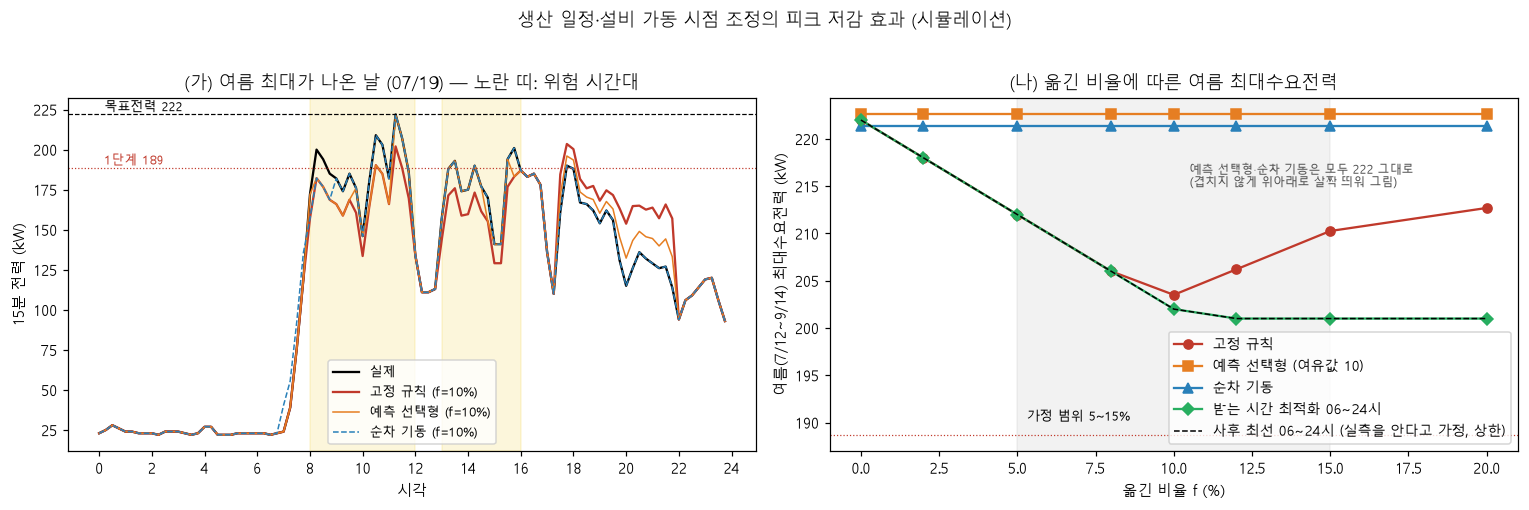

In [11]:
# 그림 22: (가) 여름 최대 날의 하루 곡선, (나) 옮긴 비율에 따른 여름 최대
peak_day = work.loc[ev, "전력"].idxmax().normalize()
g = work[work["date"] == peak_day]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
x = g.index.hour + g.index.minute / 60
ax.plot(x, g["전력"], color="black", lw=1.5, label="실제")
ax.plot(x, sims[("A", 0.10)].loc[g.index], color="#c0392b", lw=1.5, label="고정 규칙 (f=10%)")
ax.plot(x, sims[("A2", 0.10)].loc[g.index], color="#e67e22", lw=1, label="예측 선택형 (f=10%)")
ax.plot(x, sims[("C", 0.10)].loc[g.index], color="#2980b9", lw=1, ls="--", label="순차 기동 (f=10%)")
for lo, hi in [(8, 12), (13, 16)]:
    ax.axvspan(lo, hi, color="#f1c40f", alpha=0.15)
ax.axhline(TARGET, color="black", ls="--", lw=0.8); ax.axhline(L1, color="#c0392b", ls=":", lw=0.8)
ax.text(0.2, TARGET + 2, f"목표전력 {TARGET:.0f}", fontsize=8.5); ax.text(0.2, L1 + 2, f"1단계 {L1:.0f}", fontsize=8.5, color="#c0392b")
ax.set_xticks(range(0, 25, 2)); ax.set_xlabel("시각"); ax.set_ylabel("15분 전력 (kW)"); ax.legend(fontsize=8.5, loc="lower center")
ax.set_title(f"(가) 여름 최대가 나온 날 ({peak_day:%m/%d}) — 노란 띠: 위험 시간대")
ax = axes[1]
fs = [0, 0.02, 0.05, 0.08, 0.10, 0.12, 0.15, 0.20]
for name, fn, col, mk, off in [("고정 규칙", lambda f: scenario_A(f, "고정"), "#c0392b", "o", 0),
                               ("예측 선택형 (여유값 10)", lambda f: scenario_A(f, "예측"), "#e67e22", "s", 0.6),
                               ("순차 기동", scenario_C, "#2980b9", "^", -0.6)]:
    mx = [work.loc[ev, "전력"].max() if f == 0 else fn(f)[ev].max() for f in fs]
    ax.plot([f * 100 for f in fs], np.array(mx) + off, marker=mk, color=col, label=name, lw=1.5)
mx_lp = [work.loc[ev, "전력"].max() if f == 0 else scenario_LP(f, 24)[ev].max() for f in fs]
mx_or = [work.loc[ev, "전력"].max() if f == 0 else scenario_LP(f, 24, source="실측")[ev].max() for f in fs]
ax.plot([f * 100 for f in fs], mx_lp, marker="D", color="#27ae60", lw=1.5, label="받는 시간 최적화 06~24시")
ax.plot([f * 100 for f in fs], mx_or, color="black", lw=1, ls="--", label="사후 최선 06~24시 (실측을 안다고 가정, 상한)")
ax.text(10.5, TARGET - 7, "예측 선택형·순차 기동은 모두 222 그대로\n(겹치지 않게 위아래로 살짝 띄워 그림)", fontsize=8, color="#555")
ax.axhline(L1, color="#c0392b", ls=":", lw=0.8)
ax.axvspan(5, 15, color="gray", alpha=0.1); ax.text(5.3, L1 + 1.5, "가정 범위 5~15%", fontsize=8.5)
ax.set_xlabel("옮긴 비율 f (%)"); ax.set_ylabel("여름(7/12~9/14) 최대수요전력 (kW)"); ax.legend(fontsize=9)
ax.set_title("(나) 옮긴 비율에 따른 여름 최대수요전력")
fig.suptitle("생산 일정·설비 가동 시점 조정의 피크 저감 효과 (시뮬레이션)", y=1.02)
fig.tight_layout(); save_fig(fig, "f22_피크저감_시뮬레이션"); plt.show()

**해석**
- (가) 여름 최대가 나온 7/19(월)를 보면, 고정 규칙형(빨강)은 11:15의 222 피크를 202로 낮춥니다. 옮겨 간 부하는 17:30 이후와 저녁에 나타나고, **17:45에 약 204까지 올라 이날의 새 최대**가 됩니다. 이날은 일요일 다음 날이라 06~08시에 받지 못하고, 점심·저녁 휴게시간도 받지 않기 때문입니다.
- 예측 기반형(주황)은 오전 피크 일부를 낮추지만, 11:15는 위험 칸으로 뽑히지 않아 그대로 남습니다.
- (나) 옮기는 비율을 늘리면 고정 규칙형의 여름 최대는 10% 부근에서 가장 낮고(약 203.5), 그보다 많이 옮기면 다시 오릅니다(15%에서 210.3, 20%에서 약 213). 예측 기반형(여유값 10)과 순차 기동은 여름 최대를 낮추지 못합니다.
- (나)의 초록 선(LP 받는 칸 06~24시)은 받는 칸을 최적으로 채우고 22~24시까지 넓힌 경우입니다(3-3). f가 10%를 넘어도 다시 오르지 않고(15·20%에서 201.0), 모든 f에서 검은 점선(실측을 안다고 가정한 사후 최선)과 겹칩니다. **받는 칸 병목은 '배치 방법'과 '받는 시간 범위'로 풀 수 있다**는 뜻입니다. 단, 야간조가 옮긴 작업을 맡는다는 전제가 필요합니다.
- **결론**: 요금을 정하는 '단 한 번의 피크'를 막으려면, 예측에만 의존하지 말고 **위험 시간대에는 배치형 설비를 돌리지 않는다는 고정 규칙**을 기본으로 두는 것이 안전합니다. 예측과 경보는 그 위에서 일상적인 피크를 관리하고, **받는 칸이 넘치지 않는지 당일 다시 확인**하는 데 씁니다. 받는 칸이 이 방안의 병목입니다.

### 3-4. 규칙을 얼마나 잘 지켜야 하나 — 몬테카를로 강건성 분석

**왜 하나**
- 앞의 203.5kW(연 약 160만 원)는 **'옮길 수 있는 부하 f가 매일 10%로 똑같고, 42일 동안 하루도 빠짐없이 규칙을 지킨다'**는 가정의 결과입니다.
- 현실에서는 두 가지가 흔들립니다.
  - **f가 날마다 다릅니다.** 그날 만드는 품목과 열처리 일정에 따라 옮길 수 있는 설비의 양이 달라집니다.
  - **규칙을 못 지키는 날이 있습니다.** 급한 주문, 설비 고장, 담당자 부재 등입니다.
- 기본요금은 여름 중 **가장 나쁜 하루의 15분**으로 정해집니다. 그래서 '평균적으로 잘 지켰는가'보다 **'가장 위험한 날에 지켰는가'**가 결과를 좌우할 수 있습니다. 이를 확인하려고 같은 계산을 4,000번 반복했습니다.

**방법**
1. A1(고정 규칙형)을 '가동일 × 96칸' 배열로 다시 계산하는 함수를 만들었습니다. 위의 `scenario_A` 결과(f = 5·10·15%에서 212.0·203.5·210.3)와 같은지 먼저 확인합니다.
2. 매번 다음을 무작위로 정합니다(시드 42).
   - 날마다 f를 5~15%에서 고르게 뽑음
   - 날마다 '규칙을 지켰는가'를 준수율 p의 확률로 정함
3. 정책 두 가지를 비교합니다.
   - **균일 준수**: 모든 날을 같은 확률 p로 지킴
   - **주의일 반드시 준수**: 주의일(월요일 등 전날 쉰 가동일)은 반드시 지키고, 나머지 날만 확률 p
4. 각 경우의 여름(7/12~9/14) 최대수요전력과 **연 기본요금 절감**(선택Ⅰ, 7,220원/kW·월 × 12개월)의 분포를 봅니다.
   - 기대값
   - 5% 분위(20번 중 1번 정도 겪는 나쁜 경우)
   - **'절감 0원' 확률**(여름 최대가 222 그대로 남는 확률)

In [12]:
# 3-4. A1의 배열 버전 + 몬테카를로 (f와 준수율의 불확실성)
days_mc = sorted(work["date"].unique()); D_MC = len(days_mc)
P_mc = np.full((D_MC, 96), np.nan); PR_mc = np.full((D_MC, 96), np.nan); PREV_mc = np.zeros(D_MC, bool)
EV_mc = np.zeros((D_MC, 96), bool)                                  # 효과 평가 칸(정답사용)
for i, d in enumerate(days_mc):
    g = work[work["date"] == d]; s = g["칸번호"].values
    P_mc[i, s] = g["전력"].values; PR_mc[i, s] = g["예측"].values; PREV_mc[i] = bool(g["전날가동"].iloc[0])
    EV_mc[i, s] = g["정답사용"].values
OK_mc = ~np.isnan(P_mc)
hh = np.arange(96) // 4; mm = (np.arange(96) % 4) * 15
DON_mc = np.tile(RISK(hh), (D_MC, 1)) & OK_mc                       # 위험 시간대(빼는 칸)
REC_mc = np.tile((hh >= 6) & (hh < 22) & ~RISK(hh) & (hh != 16) & ~((hh == 12) | ((hh == 17) & (mm < 30))), (D_MC, 1))
REC_mc[~PREV_mc] &= (hh >= 8)                                        # 전날 쉰 날은 06~08시 받지 않음 (receivers와 같음)
REC_mc &= OK_mc
P0_mc = np.nan_to_num(P_mc, nan=0.0)
HEAD_mc = np.clip(CAP - np.nan_to_num(PR_mc, nan=CAP), 0, None) * REC_mc   # 받는 칸 여유 (하루 앞 예측 기준, receive와 같음)
ROOM_mc = HEAD_mc.sum(1)
AMT_mc = np.clip(P0_mc - BASE, 0, None) * DON_mc; TOT_mc = AMT_mc.sum(1)

def a1_new(f_day, comply):
    """f_day, comply: (반복 수, 가동일 수) → 조정 후 전력 (반복 수, 가동일 수, 96)"""
    take = np.where(comply, np.minimum(f_day * TOT_mc, ROOM_mc), 0.0)
    frac = np.where(TOT_mc > 0, take / np.maximum(TOT_mc, 1e-9), 0.0)
    new = P0_mc[None] - frac[..., None] * AMT_mc[None] + (take / np.maximum(ROOM_mc, 1e-9))[..., None] * HEAD_mc[None]
    return np.where((OK_mc & EV_mc)[None], new, -np.inf)          # 평가는 정답사용 칸만

def a1_array(f_day, comply):
    """반복마다 여름 최대수요전력"""
    return a1_new(f_day, comply).max(axis=(1, 2))

for f in [0.05, 0.10, 0.15]:     # 위의 scenario_A(고정)와 같은 결과인지 확인
    arr = a1_array(np.full((1, D_MC), f), np.ones((1, D_MC), bool))[0]
    assert abs(arr - scenario_A(f, "고정")[ev].max()) < 1e-6, (f, arr)
print("배열 버전 확인: f=5/10/15% →", [round(a1_array(np.full((1, D_MC), f), np.ones((1, D_MC), bool))[0], 1) for f in (0.05, 0.10, 0.15)])

N_MC = 4000
PEAK0 = work.loc[ev, "전력"].max()
WON_PER_KW = TARIFF[BASE_TARIFF]["기본"] * 12                       # 원/kW·년
FOCUS = ~PREV_mc                                                    # 주의일: 전날 쉰 가동일
print(f"주의일 {FOCUS.sum()}일 / 가동일 {D_MC}일:", [pd.Timestamp(days_mc[i]).strftime("%m/%d") for i in np.where(FOCUS)[0]])
rng_mc = np.random.default_rng(42)

def mc_run(f_lo, f_hi, p, focus=False):
    f_day = rng_mc.uniform(f_lo, f_hi, (N_MC, D_MC))
    comply = rng_mc.random((N_MC, D_MC)) < p
    if focus: comply |= FOCUS[None]
    peak = a1_array(f_day, comply)
    return peak, (PEAK0 - peak) * WON_PER_KW

def mc_summary(peak, saving):
    return {"기대 절감(만 원/년)": round(saving.mean() / 1e4, 1), "5% 분위 절감(만 원/년)": round(np.percentile(saving, 5) / 1e4, 1),
            "절감 0원 확률(%)": round(100 * np.mean(peak >= PEAK0 - 1e-6), 1),
            "여름 최대 중앙값(kW)": round(np.median(peak), 1), "여름 최대 95% 분위(kW)": round(np.percentile(peak, 95), 1)}

rows = {("참고: f 10% 고정", "매일 준수", 100): mc_summary(*mc_run(0.10, 0.10, 1.0))}
for focus, pol in [(False, "균일 준수"), (True, "주의일 반드시 준수")]:
    for p in [1.0, 0.95, 0.90, 0.80]:
        if focus and p == 1.0: continue
        rows[("f 5~15% (날마다)", pol, int(p * 100))] = mc_summary(*mc_run(0.05, 0.15, p, focus))
mc_tab = pd.DataFrame(rows).T
mc_tab.index.names = ["옮길 수 있는 부하", "정책", "준수율(%)"]
save_table(mc_tab, "t42_몬테카를로_강건성")

# 그림 왼쪽: f 평균 × 준수율 지도 (날마다 f 평균 ± 5%p, 0 미만은 0)
F_MEANS = [0.05, 0.075, 0.10, 0.125, 0.15]; PS = [1.0, 0.98, 0.95, 0.90, 0.80, 0.70]
heat_sav = np.zeros((len(PS), len(F_MEANS))); heat_zero = np.zeros_like(heat_sav)
for j, fm in enumerate(F_MEANS):
    for i, p in enumerate(PS):
        pk, sv = mc_run(max(fm - 0.05, 0), fm + 0.05, p)
        heat_sav[i, j] = sv.mean() / 1e4; heat_zero[i, j] = 100 * np.mean(pk >= PEAK0 - 1e-6)
# 그림 오른쪽: 정책별 비용-위험 곡선 (f 5~15%)
curve_ps = [1.0, 0.98, 0.95, 0.90, 0.85, 0.80, 0.70, 0.60]
curves = {}
for focus, pol in [(False, "균일 준수"), (True, "주의일 반드시 준수")]:
    pts = []
    for p in curve_ps:
        pk, sv = mc_run(0.05, 0.15, p, focus)
        pts.append((100 * np.mean(pk >= PEAK0 - 1e-6), sv.mean() / 1e4, p))
    curves[pol] = pts

# 참고: '다른 여름' — 가동일을 날 단위로 다시 뽑은 가상의 여름 (f 10% 고정, 매일 준수)
day_before = np.where(OK_mc & EV_mc, P0_mc, -np.inf).max(1)
day_after = a1_new(np.full((1, D_MC), 0.10), np.ones((1, D_MC), bool))[0].max(1)
bi = rng_mc.integers(0, D_MC, (2000, D_MC))
boot_sav = (day_before[bi].max(1) - day_after[bi].max(1)) * WON_PER_KW / 1e4
print(f"참고 — 가동일을 다시 뽑은 가상의 여름 2,000개 (f 10% 고정, 매일 준수): 연 절감 중앙 {np.median(boot_sav):.0f}만 원 (90% 범위 {np.percentile(boot_sav, 5):.0f}~{np.percentile(boot_sav, 95):.0f}만 원)")
mc_tab

배열 버전 확인: f=5/10/15% → [np.float64(212.0), np.float64(203.5), np.float64(210.3)]
주의일 9일 / 가동일 42일: ['07/12', '07/19', '07/26', '08/09', '08/16', '08/23', '08/30', '09/06', '09/13']


참고 — 가동일을 다시 뽑은 가상의 여름 2,000개 (f 10% 고정, 매일 준수): 연 절감 중앙 160만 원 (90% 범위 139~162만 원)


기대 절감(만 원/년)  5% 분위 절감(만 원/년)  절감 0원 확률(%)  \
옮길 수 있는 부하    정책         준수율(%)                                               
참고: f 10% 고정  매일 준수      100            160.2            160.2          0.0   
f 5~15% (날마다) 균일 준수      100            127.7             95.1          0.0   
                         95             103.1             34.7          4.8   
                         90              84.2              0.0          9.9   
                         80              58.1              0.0         19.9   
              주의일 반드시 준수 95             115.1             69.3          0.0   
                         90             104.6             34.7          0.0   
                         80              87.3             34.7          0.0   

                                 여름 최대 중앙값(kW)  여름 최대 95% 분위(kW)  
옮길 수 있는 부하    정책         준수율(%)                                   
참고: f 10% 고정  매일 준수      100             203.5             203.5  
f 5~15% (날마다) 균일 준수      100             207.2             211.0  
                         95              208.9             218.0  
                         90              211.0             222.0  
                         80              215.0             222.0  
              주의일 반드시 준수 95              208.2             214.0  
                         90              209.7             218.0  
                         80              211.6             218.0

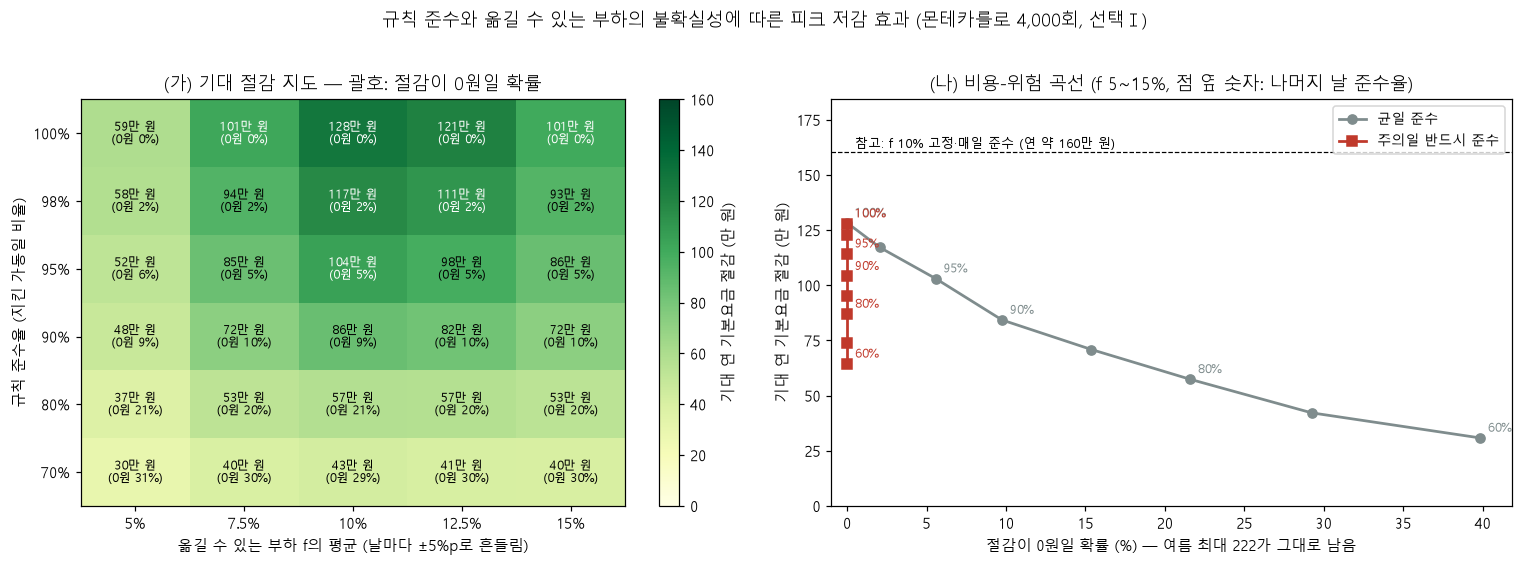

In [13]:
# 그림 23: (가) f × 준수율 지도, (나) 정책별 비용-위험 곡선
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
im = ax.imshow(heat_sav, cmap="YlGn", aspect="auto", vmin=0, vmax=max(160, heat_sav.max()))
for i in range(len(PS)):
    for j in range(len(F_MEANS)):
        ax.text(j, i, f"{heat_sav[i, j]:.0f}만 원\n(0원 {heat_zero[i, j]:.0f}%)", ha="center", va="center", fontsize=8,
                color="white" if heat_sav[i, j] > 100 else "black")
ax.set_xticks(range(len(F_MEANS))); ax.set_xticklabels([f"{fm*100:g}%" for fm in F_MEANS])
ax.set_yticks(range(len(PS))); ax.set_yticklabels([f"{p*100:.0f}%" for p in PS])
ax.set_xlabel("옮길 수 있는 부하 f의 평균 (날마다 ±5%p로 흔들림)"); ax.set_ylabel("규칙 준수율 (지킨 가동일 비율)")
fig.colorbar(im, ax=ax, label="기대 연 기본요금 절감 (만 원)")
ax.set_title("(가) 기대 절감 지도 — 괄호: 절감이 0원일 확률")
ax = axes[1]
for (pol, pts), col, mk in zip(curves.items(), ["#7f8c8d", "#c0392b"], ["o", "s"]):
    xs, ys, ps_ = zip(*pts)
    ax.plot(xs, ys, marker=mk, color=col, lw=1.8, label=pol)
    for x_, y_, p_ in zip(xs, ys, ps_):
        if p_ in (1.0, 0.95, 0.90, 0.80, 0.60):
            ax.annotate(f"{p_*100:.0f}%", (x_, y_), textcoords="offset points", xytext=(5, 4), fontsize=8, color=col)
ref = (PEAK0 - sims[("A", 0.10)].max()) * WON_PER_KW / 1e4
ax.axhline(ref, color="black", ls="--", lw=0.8)
ax.text(0.5, ref + 2, f"참고: f 10% 고정·매일 준수 (연 약 {ref:.0f}만 원)", fontsize=8.5)
ax.set_xlabel("절감이 0원일 확률 (%) — 여름 최대 222가 그대로 남음"); ax.set_ylabel("기대 연 기본요금 절감 (만 원)")
ax.set_xlim(left=-1); ax.set_ylim(0, ref * 1.15); ax.legend(fontsize=9, loc="upper right")
ax.set_title("(나) 비용-위험 곡선 (f 5~15%, 점 옆 숫자: 나머지 날 준수율)")
fig.suptitle("규칙 준수와 옮길 수 있는 부하의 불확실성에 따른 피크 저감 효과 (몬테카를로 4,000회, 선택Ⅰ)", y=1.02)
fig.tight_layout(); save_fig(fig, "f23_규칙준수_강건성"); plt.show()

**해석** — 표 42, 그림 23 (f 5~15%는 날마다 무작위, 4,000회)

| 정책 | 준수율 | 기대 절감 | 5% 분위 절감 | 절감 0원 확률 |
|---|---|---|---|---|
| 참고: f 10% 고정, 매일 준수 (표 30) | 100% | 160만 원 | 160만 원 | 0% |
| 균일 준수 | 100% | 128만 원 | 95만 원 | 0% |
| 균일 준수 | 95% | 103만 원 | 35만 원 | 4.8% |
| 균일 준수 | 90% | 84만 원 | 0원 | 9.9% |
| 균일 준수 | 80% | 58만 원 | 0원 | 19.9% |
| 주의일 반드시 준수 | 나머지 날 95% | 115만 원 | 69만 원 | 0% |
| 주의일 반드시 준수 | 나머지 날 90% | 105만 원 | 35만 원 | 0% |
| 주의일 반드시 준수 | 나머지 날 80% | 87만 원 | 35만 원 | 0% |

- **f가 날마다 흔들리기만 해도 기대 절감이 줄어듭니다.**
  - 매일 지켜도 f가 5~15%에서 날마다 달라지면, 기대 절감은 연 약 128만 원입니다(f 10% 고정이면 160만 원).
  - 여름 최대는 '가장 불리한 날'에 정해지기 때문입니다. f가 작은 날에 피크가 덜 줄고, f가 큰 날에는 받는 칸이 넘칩니다(그림 23 가에서 f 평균 10% 부근이 가장 진함).
- **준수율이 조금만 떨어져도 '절감 0원' 위험이 생깁니다.**
  - 균일 준수에서 준수율 95%면 기대 절감 103만 원, 절감 0원 확률 4.8%입니다.
  - 90%면 84만 원과 9.9%입니다.
  - 여름 최대(222)가 나온 7/19 하루를 지키지 못하면, 다른 날을 아무리 잘 지켜도 기본요금이 그대로이기 때문입니다. 절감 0원 확률이 대략 '1 − 준수율'과 같은 것도 이 때문입니다.
- **위험한 날에 준수를 모으면 '절감 0원' 위험이 사라집니다.**
  - 주의일(월요일 등 전날 쉰 가동일, 42일 중 9일)을 반드시 지키고 나머지 날 준수율이 80%이면, 4,000회 중 절감 0원은 0건이고 기대 절감은 87만 원입니다. 이때 전체 기대 준수율은 84.3%입니다.
  - 비슷한 전체 준수율인 '모든 날 고르게 90%'는 기대 절감 84만 원, 절감 0원 확률 9.9%입니다. 주의일 집중과 전체 준수율 상승이 함께 작용한 결과입니다. 0건은 이번 42일 부하와 아래 가정에서 나온 값입니다.
  - 측정 구간 하루 최대 상위 4일 중 3일(7/19 222, 7/26 217, 8/9 215)이 주의일입니다(그림 23 나: 빨간 점은 모두 '절감 0원 확률 0%' 선 위에 있음).
- **현장 운영에 주는 근거**
  - 4장의 '주의일 규칙'(월요일·휴무 직후 첫날은 사람이 직접 확인)은 경보 성능 때문만이 아니라 **요금 위험 때문에도** 필요합니다.
  - KPI '규칙 준수율 95% 이상'은 이 계산에서 절감 0원 확률이 약 5%가 되는 수준입니다. 그래서 전체 준수율과 별도로 **'주의일 준수율 100%'**를 KPI에 두는 것을 제안합니다.
- **'다른 여름'이었다면**: 가동일을 날 단위로 다시 뽑은 가상의 여름 2,000개(f 10% 고정, 매일 준수)에서도 연 절감은 중앙 160만 원(90% 범위 139~162만 원)으로 크게 흔들리지 않았습니다. 결과를 흔드는 것은 '어떤 날들이 모였나'보다 **f와 준수율**입니다.
- **한계**
  - f를 날마다 5~15%에서 고르게 뽑은 것과 날마다 준수 여부를 서로 독립으로 둔 것은 **가정**입니다. 실제 분포를 알려면 설비별 전력 기록과 규칙 준수 기록이 필요합니다.
  - 측정된 7/12~9/14 기록 위의 계산입니다. 주의일 집중이 효과적인 것은 이번 여름의 최대일이 월요일이었던 영향도 있습니다.

### 3-5. 예측이 빗나갈 때를 대비한 받는 칸 배치

**무엇이 문제인가**
- 3-3절의 받는 칸 LP는 **하루 앞 예측(점예측) 하나**만 보고 배치합니다. 예측이 빗나가면 받는 칸이 예상보다 높아질 수 있습니다.
- 받는 칸을 06~24시로 넓히면 **여름 최대는 이미 바닥**입니다(10% 202.0, 15% 201.0kW). 이 값은 빼는 쪽(7/19 11:15, 7/20 16:00)에서 정해지고, 오라클과 같습니다. 받는 쪽을 아무리 잘 배치해도 요금은 더 줄지 않습니다.
- 남은 위험은 **받는 칸이 새로 1단계를 넘는 일(넘침)**입니다. 경보가 울리고 현장이 대응해야 하는 일이며, 운이 나쁘면 새 피크가 됩니다. 표 39에서 10%는 5칸, 15%는 12칸이었습니다.
- 그래서 **예측 오차를 고려해 배치하면 넘침을 줄일 수 있는지**, 그리고 요금 효과를 잃지 않는지 확인합니다.

**비교하는 배치 방법** (빼는 쪽은 모두 A1 고정 규칙, 받는 칸 06~24시)

| 방법 | 어떻게 배치하나 |
|---|---|
| 점예측 LP | 3-3절 그대로. $\min Z$, $\hat P_t + a_t \le Z$ |
| 확률 제약 | 칸마다 '예측 + 그 칸의 예측구간 위쪽 끝'으로 높이를 맞춤. $\hat P_t + q_t^{1-\varepsilon} + a_t \le Z$. 넘칠 확률을 칸마다 ε 이하로 두려는 방식 |
| CVaR90 | 과거 25개 가동일의 하루 잔차 곡선을 시나리오로 두고, 시나리오별 받는 칸 최대의 **나쁜 쪽 10% 평균**을 최소화 (이전에 시도했다가 실패한 방법을 재현) |
| 시나리오 기대값 | 잔차를 2시간 블록 단위로 다시 뽑아 시나리오 300개를 만들고, 받는 칸 최대의 **시나리오 평균**을 최소화. $\min \frac1S\sum_s Z_s$, $\hat P_t + e_{st} + a_t \le Z_s$ |
| 오라클 | 실측을 미리 안다고 보고 배치한 상한 |

- **예측구간과 시나리오는 모두 '그날 이전' 가동일의 잔차만** 씁니다(정보 누출 없음).
  - 예측구간은 conformal 방식입니다. 같은 시각 ±1시간의 과거 잔차 n개 중 ⌈(n+1)(1−ε)⌉번째 값을 씁니다.
  - 7월 중순에는 쌓인 날이 10~15일뿐입니다.
- **기간**: 7/12~9/14(기준 곡선 예측)와 시험 기간 8/9~9/14(최종 하루 앞 모델)를 따로 봅니다.
- **설정값은 미리 정했습니다**: ε = 10%, 시나리오 300개, 블록 2시간, 시드 42. 시험 기간 결과를 보고 고르지 않았습니다.
- 넘침 수의 차이에는 **날짜 단위 95% 범위**를 붙입니다. 가동일을 날 단위로 다시 뽑아 2,000번 계산한 범위입니다.

In [14]:
# 3-5. 예측 불확실성을 고려한 받는 칸 배치 (빼는 쪽은 A1 고정 규칙, 받는 칸 06~24시)
from scipy.sparse import coo_matrix
SEED = 42
S_SCEN = 300                                   # 블록 부트스트랩 시나리오 수
BLOCK = 8                                      # 블록 길이 (8칸 = 2시간)
TEST0 = pd.Timestamp("2021-08-09")
MASKS = {"7/12~9/14": ev.values, "시험 8/9~9/14": np.asarray(work.index >= TEST0) & ev.values}   # 평가는 정답사용 칸만
SRC = {"7/12~9/14": ("기준곡선", None), "시험 8/9~9/14": ("최종모델", TEST0)}

def new_over_count(new, mask):
    a, b = work.loc[mask, "전력"], new[mask]
    return int(((b >= L1) & (a < L1)).sum())

# (0) 3-3절 표 39·40의 값이 그대로 재현되는지 확인
for f in (0.10, 0.15):
    new = scenario_LP(f, 24); row = t39.loc[(f, "LP 받는 칸 06~24시")]
    assert round(new[MASKS["7/12~9/14"]].max(), 1) == row["조정 후 최대수요전력"]
    assert new_over_count(new, MASKS["7/12~9/14"]) == row["그중 새로 넘은 칸(받는 칸)"]
assert round(scenario_LP(0.15, 24, source="최종모델", mpc=True, start=TEST0)[MASKS["시험 8/9~9/14"]].max(), 1) == \
       t40.loc[(0.15, "재계획 + 받는 칸 22~24시"), "조정 후 최대수요전력"]
print("표 39·40 재현 확인 완료 (정답사용 칸 기준)")

# (1) 하루 앞 예측의 잔차 풀: '그날 이전' 가동일만 씀 (7/1~7/11도 같은 방식의 기준 곡선으로 잔차를 만들어 풀을 넓힘)
early = slots[(slots["하루종류"] == "평일가동") & (slots.index < "2021-07-12")].copy()
early["예측"] = np.nan
for d in early["date"].unique():
    hist = slots[(slots.index < d) & slots["정답사용"]]
    if hist.empty: continue
    curve = hist.groupby(CURVE_KEYS)["전력"].mean().rename("c")
    idx = early.index[early["date"] == d]
    early.loc[idx, "예측"] = early.loc[idx].join(curve, on=CURVE_KEYS)["c"].values
pool_curve = pd.concat([early, work])[["date", "전력", "정답사용", "예측"]]
pool_curve = pool_curve[pool_curve["정답사용"] & pool_curve["예측"].notna() & pool_curve["전력"].notna()]
pool_curve = pd.DataFrame({"date": pool_curve["date"], "잔차": pool_curve["전력"] - pool_curve["예측"]})
pool_final = pd.DataFrame({"date": work["date"], "잔차": work["전력"] - day_final.reindex(work.index)})
pool_final = pool_final[(pool_final.index >= TEST0) & work["정답사용"] & pool_final["잔차"].notna()]
for p in (pool_curve, pool_final):
    p["k"] = p.index.hour * 4 + p.index.minute // 15

def resid_pool(d, src):
    """기준곡선: 그날 이전 기준 곡선 잔차. 최종모델: 8/9 이전은 기준 곡선 잔차, 8/9부터 그날 이전은 최종 모델 잔차"""
    r = pool_curve[pool_curve["date"] < d]
    if src == "최종모델":
        r = pd.concat([r[r["date"] < TEST0], pool_final[pool_final["date"] < d]])
    return r

def conformal_q(d, src, R, eps):
    """칸별 (1−ε) conformal 분위수: 같은 시각 ±1시간 과거 잔차 n개 중 ⌈(n+1)(1−ε)⌉번째 값"""
    r = resid_pool(d, src); v_all = r["잔차"].values; k_all = r["k"].values
    out = np.empty(len(R))
    for i, t in enumerate(R):
        v = np.sort(v_all[np.abs(k_all - (t.hour * 4 + t.minute // 15)) <= 4]); n = len(v)
        out[i] = v[min(int(np.ceil((n + 1) * (1 - eps))), n) - 1] if n >= 10 else 15.0
    return out

def resid_days(d, src):
    piv = resid_pool(d, src).pivot_table(index="date", columns="k", values="잔차").reindex(columns=range(96))
    return piv

def scen_whole25(d, src, R):
    """이전 시도(실패 재현): 최근 25개 가동일의 하루 잔차 곡선을 통째로 시나리오로"""
    piv = resid_days(d, src).tail(25)[[t.hour * 4 + t.minute // 15 for t in R]]
    return piv.apply(lambda c: c.fillna(c.median() if c.notna().any() else 0.0)).values

def scen_block_boot(d, src, R):
    """블록 부트스트랩: 96칸을 2시간 블록으로 나눠 블록마다 과거 가동일 하나의 같은 시각 잔차를 붙임 (경계는 무작위로 밀기)"""
    M = resid_days(d, src).values
    M = np.where(np.isnan(M), np.nan_to_num(np.nanmedian(M, axis=0))[None], M)
    rng = np.random.default_rng(SEED + pd.Timestamp(d).dayofyear)
    out = np.empty((S_SCEN, 96))
    for s in range(S_SCEN):
        for st in range(-int(rng.integers(0, BLOCK)), 96, BLOCK):
            lo, hi = max(st, 0), min(st + BLOCK, 96)
            out[s, lo:hi] = M[rng.integers(0, M.shape[0]), lo:hi]
    return out[:, [t.hour * 4 + t.minute // 15 for t in R]]

def lp_scen(fc, E, cost, scen, alpha):
    """시나리오 LP. alpha=0: min W·평균(Z_s) + cost·a / alpha>0: min W·CVaR_α(Z_s) + cost·a.  Z_s ≥ fc + e_s + a, Σa = E"""
    S, n = scen.shape
    nv = n + S + 1 + S                                    # a(n), Z(S), η, u(S)
    ss, tt = np.meshgrid(np.arange(S), np.arange(n), indexing="ij"); ss, tt = ss.ravel(), tt.ravel(); m = S * n
    rows = [np.arange(m), np.arange(m), m + np.arange(S), m + np.arange(S), m + np.arange(S), np.full(n, m + S)]
    cols = [tt, n + ss, n + np.arange(S), np.full(S, n + S), n + S + 1 + np.arange(S), np.arange(n)]
    vals = [np.ones(m), -np.ones(m), np.ones(S), -np.ones(S), -np.ones(S), np.ones(n)]
    A = coo_matrix((np.concatenate(vals), (np.concatenate(rows), np.concatenate(cols))), shape=(m + S + 1, nv)).tocsr()
    lo = np.r_[np.full(m + S, -np.inf), E]; hi = np.r_[-(fc[None] + scen).ravel(), np.zeros(S), E]
    c = np.zeros(nv); c[:n] = cost
    if alpha <= 0: c[n:n + S] = W_PEAK / S
    else: c[n + S] = W_PEAK; c[n + S + 1:] = W_PEAK / ((1 - alpha) * S)
    lb = np.r_[np.zeros(n), np.full(S + 1, -np.inf), np.zeros(S)]
    res = milp(c, constraints=LinearConstraint(A, lo, hi), bounds=Bounds(lb, np.full(nv, np.inf)))
    assert res.success, res.message
    return res.x[:n]

def scenario_unc(f, method, period, eps=0.10):
    """method: 점예측 | 확률제약 | CVaR90 | 시나리오기대값 | 오라클. 예측으로 정한 배치를 실측에 더해 평가.
    확률제약일 때는 conformal 구간의 실제 적중 여부도 돌려줌."""
    src, start = SRC[period]
    level = {"기준곡선": work["예측"], "최종모델": day_final}[src]
    out = work["전력"].copy(); hits = []
    for d, g in work.groupby("date"):
        if start is not None and d < start: continue
        donors = g.index[RISK(g.index.hour) & ok.loc[g.index]]
        amt = (g.loc[donors, "전력"] - BASE).clip(lower=0) * f
        if amt.sum() == 0: continue
        R = receivers_lp(g, 24); E = amt.sum()
        cost = 0.25 * PRICE.loc[R].values
        fc = level.loc[R].values.astype(float); act = work.loc[R, "전력"].values.astype(float)
        if method == "점예측": a = lp_receive(fc, E, cost)
        elif method == "오라클": a = lp_receive(act, E, cost)
        elif method == "확률제약":
            q = conformal_q(d, src, R, eps); a = lp_receive(fc + q, E, cost)
            use = work.loc[R, "정답사용"].values
            hits += list((act - fc > q)[use])
        elif method == "CVaR90": a = lp_scen(fc, E, cost, scen_whole25(d, src, R), 0.9)
        elif method == "시나리오기대값": a = lp_scen(fc, E, cost, scen_block_boot(d, src, R), 0.0)
        out.loc[donors] -= amt; out.loc[R] += a
    return out, (float(np.mean(hits)) if hits else np.nan)

def day_range(new, base, mask, n=2000):
    """날짜 단위 부트스트랩(시드 42): 새로 넘은 받는 칸 수와 여름 최대의 차이(방안 − 점예측) 95% 범위"""
    a = work.loc[mask, "전력"]; dd = work.loc[mask, "date"]
    cn = ((new[mask] >= L1) & (a < L1)).groupby(dd).sum(); cb = ((base[mask] >= L1) & (a < L1)).groupby(dd).sum()
    mn = new[mask].groupby(dd).max(); mb = base[mask].groupby(dd).max()
    keep = mn.notna() & mb.notna(); cn, cb, mn, mb = cn[keep], cb[keep], mn[keep], mb[keep]
    idx = np.random.default_rng(SEED).integers(0, len(cn), (n, len(cn)))
    dc = (cn.values - cb.values)[idx].sum(1); dm = mn.values[idx].max(1) - mb.values[idx].max(1)
    return (f"{int((cn - cb).sum()):+d} ({np.percentile(dc, 2.5):+.0f}~{np.percentile(dc, 97.5):+.0f})",
            f"{mn.max() - mb.max():+.1f} ({np.percentile(dm, 2.5):+.1f}~{np.percentile(dm, 97.5):+.1f})")

UNC_METHODS = [("점예측 LP (3-3절)", "점예측"), ("확률 제약 (칸별 conformal 여유, ε=10%)", "확률제약"),
               ("CVaR90 (최근 25일 하루 잔차, 이전 시도 재현)", "CVaR90"),
               ("시나리오 기대값 (블록 부트스트랩 300개)", "시나리오기대값"), ("오라클 (실측, 상한)", "오라클")]
rows, unc_sims = [], {}
for period, mask in MASKS.items():
    for f in [0.10, 0.15]:
        base = None
        for name, m in UNC_METHODS:
            new, _ = unc_sims[(period, f, m)] = scenario_unc(f, m, period)
            if m == "점예측": base = new
            a, b = work.loc[mask, "전력"], new[mask]
            assert abs((a - b).groupby(work.loc[mask, "date"]).sum()).max() < 1e-6          # 하루 전력량 보존
            over_rng, max_rng = day_range(new, base, mask) if m != "점예측" else ("–", "–")
            rows.append({"기간": period, "옮긴 비율 f": f, "방안": name, "여름 최대(kW)": round(b.max(), 1),
                         "여름 최대 차이(점예측 대비, 95% 범위)": max_rng,
                         "1단계 초과 칸": int((b >= L1).sum()), "새로 넘은 받는 칸": new_over_count(new, mask),
                         "새로 넘은 받는 칸 차이(점예측 대비, 95% 범위)": over_rng,
                         "넘친 날": int(((b >= L1) & (a < L1)).groupby(work.loc[mask, "date"]).any().sum()),
                         "전력량요금 변화(원)": round(float(((b - a) * 0.25 * PRICE[mask]).sum()))})
t47 = pd.DataFrame(rows).set_index(["기간", "옮긴 비율 f", "방안"])
save_table(t47, "t47_불확실성_받는칸배치")
t47

표 39·40 재현 확인 완료 (정답사용 칸 기준)


여름 최대(kW)  \
기간          옮긴 비율 f 방안                                           
7/12~9/14   0.10    점예측 LP (3-3절)                        202.0   
                    확률 제약 (칸별 conformal 여유, ε=10%)       204.7   
                    CVaR90 (최근 25일 하루 잔차, 이전 시도 재현)      219.0   
                    시나리오 기대값 (블록 부트스트랩 300개)             202.0   
                    오라클 (실측, 상한)                         202.0   
            0.15    점예측 LP (3-3절)                        201.0   
                    확률 제약 (칸별 conformal 여유, ε=10%)       204.7   
                    CVaR90 (최근 25일 하루 잔차, 이전 시도 재현)      219.0   
                    시나리오 기대값 (블록 부트스트랩 300개)             201.0   
                    오라클 (실측, 상한)                         201.0   
시험 8/9~9/14 0.10    점예측 LP (3-3절)                        198.4   
                    확률 제약 (칸별 conformal 여유, ε=10%)       198.4   
                    CVaR90 (최근 25일 하루 잔차, 이전 시도 재현)      198.4   
                    시나리오 기대값 (블록 부트스트랩 300개)             198.4   
                    오라클 (실측, 상한)                         198.4   
            0.15    점예측 LP (3-3절)                        194.0   
                    확률 제약 (칸별 conformal 여유, ε=10%)       198.1   
                    CVaR90 (최근 25일 하루 잔차, 이전 시도 재현)      198.8   
                    시나리오 기대값 (블록 부트스트랩 300개)             194.0   
                    오라클 (실측, 상한)                         194.0   

                                                    여름 최대 차이(점예측 대비, 95% 범위)  \
기간          옮긴 비율 f 방안                                                         
7/12~9/14   0.10    점예측 LP (3-3절)                                          –   
                    확률 제약 (칸별 conformal 여유, ε=10%)          +2.7 (+0.0~+7.2)   
                    CVaR90 (최근 25일 하루 잔차, 이전 시도 재현)       +17.0 (+0.0~+21.5)   
                    시나리오 기대값 (블록 부트스트랩 300개)                +0.0 (+0.0~+0.0)   
                    오라클 (실측, 상한)                            +0.0 (+0.0~+0.0)   
            0.15    점예측 LP (3-3절)                                          –   
                    확률 제약 (칸별 conformal 여유, ε=10%)          +3.7 (+0.0~+7.7)   
                    CVaR90 (최근 25일 하루 잔차, 이전 시도 재현)       +18.0 (+0.0~+22.0)   
                    시나리오 기대값 (블록 부트스트랩 300개)                +0.0 (-5.0~+0.0)   
                    오라클 (실측, 상한)                            +0.0 (-5.0~+0.0)   
시험 8/9~9/14 0.10    점예측 LP (3-3절)                                          –   
                    확률 제약 (칸별 conformal 여유, ε=10%)          +0.0 (+0.0~+3.7)   
                    CVaR90 (최근 25일 하루 잔차, 이전 시도 재현)         +0.0 (+0.0~+9.3)   
                    시나리오 기대값 (블록 부트스트랩 300개)                +0.0 (+0.0~+0.0)   
                    오라클 (실측, 상한)                            +0.0 (+0.0~+0.0)   
            0.15    점예측 LP (3-3절)                                          –   
                    확률 제약 (칸별 conformal 여유, ε=10%)          +4.1 (+0.0~+4.2)   
                    CVaR90 (최근 25일 하루 잔차, 이전 시도 재현)        +4.8 (+2.6~+10.8)   
                    시나리오 기대값 (블록 부트스트랩 300개)                +0.0 (+0.0~+0.0)   
                    오라클 (실측, 상한)                            +0.0 (+0.0~+0.0)   

                                                     1단계 초과 칸  새로 넘은 받는 칸  \
기간          옮긴 비율 f 방안                                                      
7/12~9/14   0.10    점예측 LP (3-3절)                          23           1   
                    확률 제약 (칸별 conformal 여유, ε=10%)         32          10   
                    CVaR90 (최근 25일 하루 잔차, 이전 시도 재현)        67          45   
                    시나리오 기대값 (블록 부트스트랩 300개)               22           0   
                    오라클 (실측, 상한)                           32          10   
            0.15    점예측 LP (3-3절)                          14           4   
                    확률 제약 (칸별 conformal 여유, ε=10%)         25          15   
                    CVaR90 (최근 25일 하루 잔차, 이전 시도 재현)        76          66   
                    시나리오 기대값 (블록 부트스트랩 300개)               10        

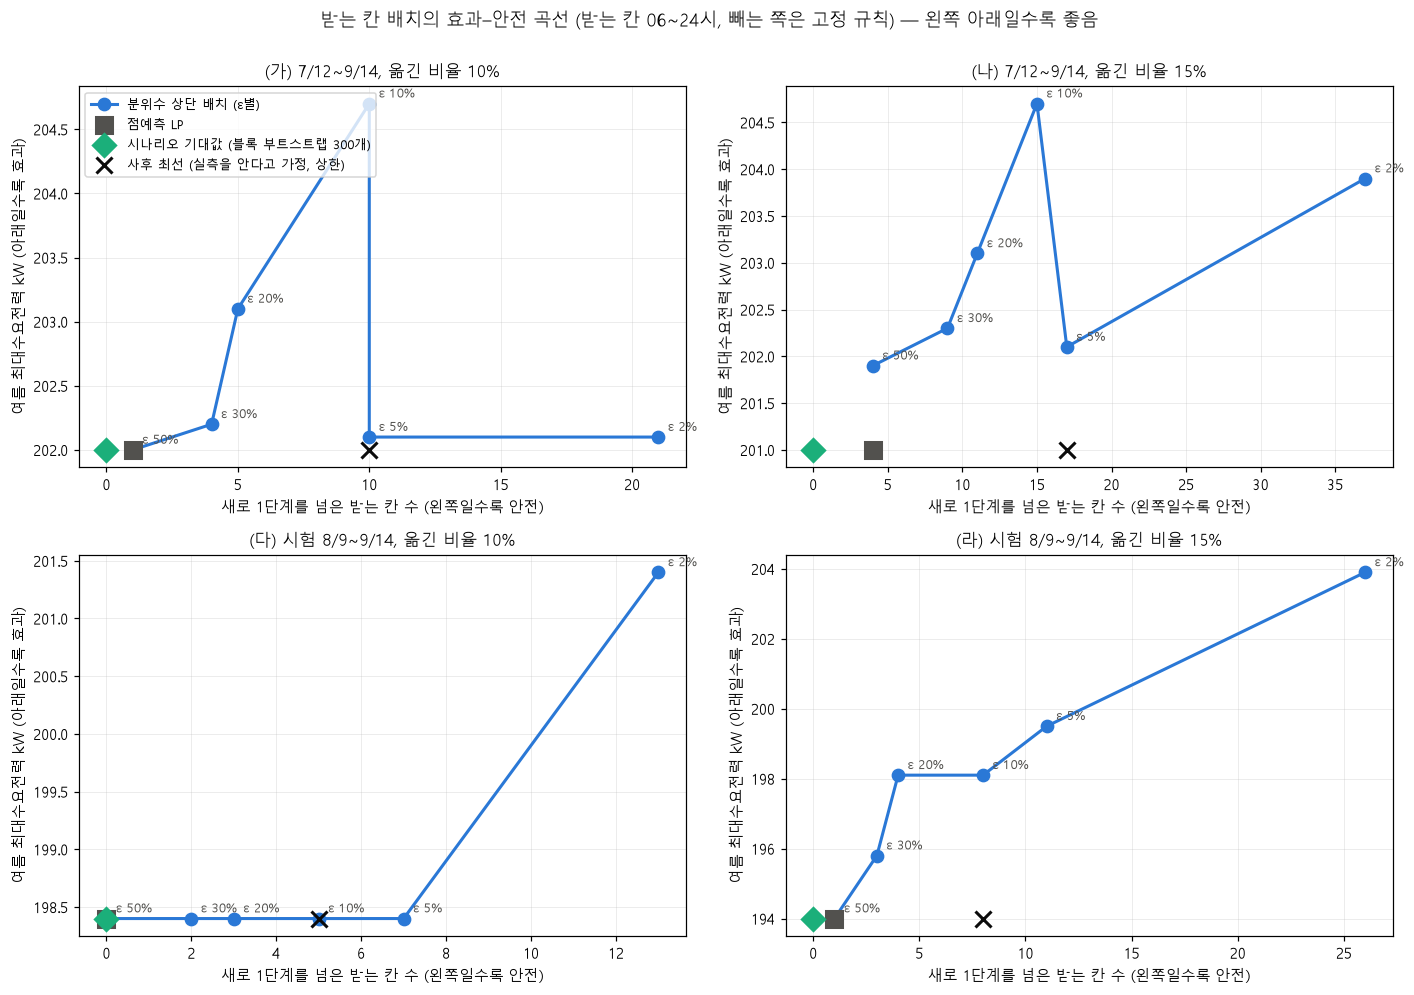

예측구간을 실제로 넘은 비율  여름 최대(kW)  1단계 초과 칸  \
기간          옮긴 비율 f 방안       넘칠 확률 목표 ε                                         
7/12~9/14   0.10    확률 제약    0.02                  0.021      202.1        43   
                             0.05                  0.052      202.1        32   
                             0.10                  0.121      204.7        32   
                             0.20                  0.228      203.1        27   
                             0.30                  0.337      202.2        26   
                             0.50                  0.539      202.0        23   
                    점예측 LP   NaN                     NaN      202.0        23   
                    시나리오 기대값 NaN                     NaN      202.0        22   
                    오라클      NaN                     NaN      202.0        32   
            0.15    확률 제약    0.02                  0.021      203.9        47   
                             0.05                  0.052      202.1        27   
                             0.10                  0.121      204.7        25   
                             0.20                  0.228      203.1        21   
                             0.30                  0.337      202.3        19   
                             0.50                  0.539      201.9        14   
                    점예측 LP   NaN                     NaN      201.0        14   
                    시나리오 기대값 NaN                     NaN      201.0        10   
                    오라클      NaN                     NaN      201.0        27   
시험 8/9~9/14 0.10    확률 제약    0.02                  0.008      201.4        21   
                             0.05                  0.031      198.4        15   
                             0.10                  0.103      198.4        13   
                             0.20                  0.198      198.4        11   
                             0.30                  0.302      198.4        10   
                             0.50                  0.502      198.4         8   
                    점예측 LP   NaN                     NaN      198.4         8   
                    시나리오 기대값 NaN                     NaN      198.4         8   
                    오라클      NaN                     NaN      198.4        13   
            0.15    확률 제약    0.02                  0.008      203.9        30   
                             0.05                  0.031      199.5        15   
                             0.10                  0.103      198.1        12   
                             0.20                  0.198      198.1         8   
                             0.30                  0.302      195.8         7   
                             0.50                  0.502      194.0         5   
                    점예측 LP   NaN                     NaN      194.0         5   
                    시나리오 기대값 NaN                     NaN      194.0         4   
                    오라클      NaN                     NaN      194.0        12   

                                         새로 넘은 받는 칸  
기간          옮긴 비율 f 방안       넘칠 확률 목표 ε              
7/12~9/14   0.10    확률 제약    0.02                21  
                             0.05                10  
                             0.10                10  
                             0.20                 5  
                             0.30                 4  
                             0.50                 1  
                    점예측 LP   NaN                  1  
                    시나리오 기대값 NaN                  0  
                    오라클      NaN                 10  
            0.15    확률 제약    0.02                37  
                             0.05                17  
                             0.10                15  
                             0.20                11  
                             0.30                 9  
                             0.50                 4  
                    점예측 LP   NaN            

In [15]:
# 표 48: 넘칠 확률 목표(ε)별 결과와 예측구간의 실제 적중률 / 그림 27: 효과–안전 곡선
EPS_LIST = [0.02, 0.05, 0.10, 0.20, 0.30, 0.50]
rows = []
for period, mask in MASKS.items():
    for f in [0.10, 0.15]:
        for eps in EPS_LIST:
            new, hit = unc_sims[(period, f, "확률제약")] if eps == 0.10 else scenario_unc(f, "확률제약", period, eps)
            rows.append({"기간": period, "옮긴 비율 f": f, "방안": "확률 제약", "넘칠 확률 목표 ε": eps,
                         "예측구간을 실제로 넘은 비율": round(hit, 3), "여름 최대(kW)": round(new[mask].max(), 1),
                         "1단계 초과 칸": int((new[mask] >= L1).sum()), "새로 넘은 받는 칸": new_over_count(new, mask)})
        for name, m in [("점예측 LP", "점예측"), ("시나리오 기대값", "시나리오기대값"), ("오라클", "오라클")]:
            new = unc_sims[(period, f, m)][0]
            rows.append({"기간": period, "옮긴 비율 f": f, "방안": name, "넘칠 확률 목표 ε": np.nan,
                         "예측구간을 실제로 넘은 비율": np.nan, "여름 최대(kW)": round(new[mask].max(), 1),
                         "1단계 초과 칸": int((new[mask] >= L1).sum()), "새로 넘은 받는 칸": new_over_count(new, mask)})
t48 = pd.DataFrame(rows).set_index(["기간", "옮긴 비율 f", "방안", "넘칠 확률 목표 ε"])
save_table(t48, "t48_위험수준별_결과")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for i, period in enumerate(MASKS):
    for j, f in enumerate([0.10, 0.15]):
        ax = axes[i, j]
        d = t48.xs((period, f), level=["기간", "옮긴 비율 f"]).reset_index()
        cc = d[d["방안"] == "확률 제약"]
        ax.plot(cc["새로 넘은 받는 칸"], cc["여름 최대(kW)"], "-o", color="#2a78d6", lw=2, ms=8, label="분위수 상단 배치 (ε별)")
        for _, r in cc.iterrows():
            ax.annotate(f"ε {r['넘칠 확률 목표 ε'] * 100:.0f}%", (r["새로 넘은 받는 칸"], r["여름 최대(kW)"]),
                        textcoords="offset points", xytext=(6, 4), fontsize=8.5, color="#52514e")
        for name, col, mk in [("점예측 LP", "#52514e", "s"), ("시나리오 기대값", "#1baf7a", "D"), ("오라클", "#0b0b0b", "x")]:
            r = d[d["방안"] == name].iloc[0]
            ax.plot(r["새로 넘은 받는 칸"], r["여름 최대(kW)"], mk, color=col, ms=10, mew=2,
                    label={"점예측 LP": "점예측 LP", "시나리오 기대값": "시나리오 기대값 (블록 부트스트랩 300개)",
                           "오라클": "사후 최선 (실측을 안다고 가정, 상한)"}[name])
        ax.set_title(f"({'가나다라'[i * 2 + j]}) {period}, 옮긴 비율 {f * 100:.0f}%", fontsize=11)
        ax.set_xlabel("새로 1단계를 넘은 받는 칸 수 (왼쪽일수록 안전)"); ax.set_ylabel("여름 최대수요전력 kW (아래일수록 효과)")
        ax.grid(alpha=0.25, lw=0.6)
        if i == 0 and j == 0: ax.legend(fontsize=8.5, loc="upper left")
fig.suptitle("받는 칸 배치의 효과–안전 곡선 (받는 칸 06~24시, 빼는 쪽은 고정 규칙) — 왼쪽 아래일수록 좋음", y=1.0, fontsize=12)
fig.tight_layout(); save_fig(fig, "f27_효과_안전_곡선"); plt.show()
t48

**해석** — 표 47·48, 그림 27 (받는 칸 06~24시)

**1. 요금은 그대로이고, 넘침만 줄었습니다.**
- 점예측 LP, 시나리오 기대값, 오라클의 여름 최대는 모두 같습니다(7/12~9/14: 10% 202.0, 15% 201.0kW / 시험 기간: 198.4, 194.0kW). 날짜 단위 95% 범위도 0에 붙어 있습니다. 여름 최대가 빼는 쪽에서 정해지기 때문입니다.
- **시나리오 기대값**은 새로 1단계를 넘은 받는 칸을 0으로 만들었습니다.
  - 7/12~9/14에서 10%는 1→0칸, 15%는 4→0칸입니다(정답사용 칸 기준).
  - 차이의 날짜 단위 95% 범위는 10% −3~0, 15% −9~0으로 **모두 0을 포함합니다.** 줄어드는 방향은 보이지만 확실한 개선이라고 할 수는 없습니다.
  - 시험 기간도 10%는 0→0칸, 15%는 1→0칸(−3~0)입니다.
  - 참고: 정답에서 뺀 7/28·7/30까지 평가에 넣었던 이전 계산에서는 15%가 12→0칸(−25~−2)이었습니다. 두 날이 결과를 크게 좌우했으므로 품질 기준을 지킨 위의 값을 씁니다.
- **대가는 전력량요금입니다.** 넓게 펴서 넣느라 경부하 칸만이 아니라 중간부하 칸도 씁니다. 그래서 절감이 기간 중 약 4만 원(10%)~9만 원(15%) 줄어듭니다.
  - 기본요금 절감(연 170~210만 원)보다 작습니다.
  - 넘침은 요금이 아니라 경보·현장 대응의 문제입니다. 그래서 '확실히 낫다'기보다 **'요금을 조금 내고 경보를 줄이는 선택지'**로 봅니다.
- 3-3절의 1시간 앞 재계획(표 40)도 넘침을 줄이는 같은 역할을 합니다. 하루 앞에 시나리오로 계획하는 방법과 당일에 다시 계획하는 방법은 **같은 목적의 두 가지 길**입니다.

**2. 이번 CVaR90 배치는 왜 나빴나 — 원인은 분리하지 못함**
- CVaR90은 7/12~9/14에서 여름 최대를 219.0kW로 올렸습니다. 새로 넘은 칸은 45·66칸으로 크게 늘었습니다.
- 이 배치는 최근 25일의 하루 잔차 곡선을 시나리오로 썼고, 시나리오 기대값은 블록 부트스트랩 300개를 썼습니다. 목적함수뿐 아니라 시나리오 구성도 다르므로, 아래 설명은 **가능한 원인**입니다.
- 나쁜 쪽 10% 시나리오에서는 하루 최대가 **우리가 넣은 양과 상관없는 칸**(원래 잔차가 크게 튄 칸)에서 정해집니다. 그래서 배치를 어떻게 바꿔도 목적함수 값이 거의 변하지 않습니다(평평함).
- 목적함수가 평평하면 전력량요금 항이 싼 칸으로 배치를 끌고 가, 옮긴 에너지가 **몇 칸에 몰릴 수 있습니다**. 그 칸의 예측이 조금만 빗나가도 새 피크가 됩니다.
- 별도 시험(블록 부트스트랩 300개, 코드로 저장하지 않음)에서도 215.6kW로 나빴습니다. 다만 같은 시나리오로 평균과 CVaR를 나란히 비교한 결과는 남기지 않았으므로, '꼬리만 보는 목표 자체가 원인'이라고 단정하지는 않습니다.

**3. 분위수 상단 배치(이른바 확률 제약)는 왜 실패했나 — 옮길 양이 정해져 있으면 여유는 '어디에 몰지'만 바꿈**
- 이 방법은 칸마다 예측에 (1−ε) 분위수 여유를 더한 높이를 평탄하게 맞춥니다. ε는 **받는 칸 하나하나가 예측구간 상단을 넘을 확률**의 목표값입니다. 실제 부하에서 기준을 넘은 칸은 결과표에서 따로 셉니다.
- **예측구간 자체는 잘 맞았습니다.** 넘칠 확률 목표 5·10·20%에 실제로 넘은 비율은 7/12~9/14에서 5.2·12.1·22.8%, 시험 기간에서 3.1·10.3·19.8%입니다(표 48).
- 그래도 결과는 나빴습니다. 10% 목표에서 여름 최대가 204.7kW로 올랐고, 새로 넘은 칸이 9~11칸 늘었습니다(95% 범위가 0을 넘지 않음).
- 이유는 다음과 같습니다.
  - 그날 뺀 에너지는 **반드시 모두** 받는 칸에 넣어야 합니다. 그래서 모든 칸에 같은 여유를 더하면 배치는 바뀌지 않습니다.
  - 배치를 바꾸는 것은 **칸끼리의 여유 차이**뿐입니다. 과거에 조용했던 밤(22~24시)·이른 아침 칸은 여유가 작게 잡혀 '안전해 보이고', 에너지가 그쪽으로 몰립니다.
  - 그 칸이 드물게 튀면 새 피크가 됩니다(7/27 23:15).
- 목표를 엄하게 잡을수록(ε 2·5%) 더 안전해지지 않고 오히려 나빠집니다. 여유 차이가 커져 더 몰리기 때문입니다. ε 50%(중앙값)가 점예측과 거의 같고 가장 좋습니다(그림 27의 파란 선).
- 즉 문제는 **구간의 정확도가 아니라 구간을 쓰는 방식**입니다.

**4. 그림 27 읽는 법**
- 가로축은 새로 넘은 받는 칸 수(왼쪽일수록 안전), 세로축은 여름 최대(아래일수록 효과)입니다. 왼쪽 아래가 좋습니다.
- 파란 선(확률 제약)은 ε를 바꿔도 점예측(회색 네모)보다 왼쪽 아래로 가지 못합니다. '효과를 조금 내주고 안전을 얻는' 맞교환이 생기지 않습니다.
- 초록 마름모(시나리오 기대값)만 효과(여름 최대)를 지키면서 가장 왼쪽(넘침 0)에 있습니다.

**5. 2단계 계획(전날 계획 → 당일 조정)에 대한 주의**
- '넘칠 것 같으면 당일 22~24시로 미룬다'는 조정을 전제로 전날 계획을 세우면, 계획은 낮 칸에 더 많이 몰아 넣습니다. 미루면 된다고 믿기 때문입니다.
- 별도 시험에서 이 전날 계획만 실행하고 당일 조정을 하지 않으면, 15%에서 여름 최대가 약 216kW까지 올랐습니다.
- 따라서 2단계 계획을 쓰려면 **당일 조정을 반드시 실행한다**는 운영 약속(4장의 '옮긴 작업 시작 전 1시간 앞 예측으로 여유 재확인')이 함께 있어야 합니다. 그 약속이 없으면 이 절의 시나리오 기대값처럼 **전날 계획만으로도 안전한 배치**가 낫습니다.

**한계**
- **가동일 42일(시험 기간 27일), 여름 한 번**의 결과입니다. 7월 중순은 예측구간을 보정할 자료가 10~15일뿐입니다.
- 시나리오 기대값의 넘침 칸 감소(1~4칸)는 날짜 단위 95% 범위가 모두 0을 포함합니다. 여름 최대의 차이는 0입니다.
- 옮길 총량은 그날 실측으로 계산했습니다(3-3절과 같은 재생 실험 조건).
- '새로 넘은 받는 칸'은 1단계(188.7) 기준의 운영 지표이고, 요금에는 직접 영향이 없습니다.
- 옮길 수 있는 부하 f는 매일 같다고 두었습니다. 이 절은 **예측 오차**만 다룹니다. f의 날마다 변동과 규칙 준수 문제는 3-4절에서 다룹니다.
- **결론**: 4장의 운영 권고(고정 규칙 + 받는 칸 LP + 당일 재계획)는 바꾸지 않습니다. 예측 불확실성은 꼬리를 보수적으로 잡는 대신 **여러 시나리오에서 평균적으로 낮게 펴서 넣는 방식**으로 다루는 것이 이 공장의 문제에 맞습니다.

### 3-6. 투자 판단 — 요금제, 운영 규칙, ESS의 순서

**왜 보나**
- 지금까지의 방안은 모두 **설비 투자 없이** 운영만 바꾸는 것입니다. 그런데 현장에서는 "에너지저장장치(ESS)를 사는 게 낫지 않나?"라는 질문이 함께 나옵니다.
- 그래서 같은 기준에서 다음을 **한 번에** 정하는 혼합정수계획(MILP)을 풉니다.
  - 요금제(선택Ⅰ/Ⅱ)
  - 운영 규칙(A1 적용 여부)
  - ESS 설치 여부·용량(kWh)·출력(kW)과 15분마다의 충방전
  - 연간 피크 목표 Z

**정식화** (`scipy.optimize.milp`)

$$\min\; 12\,B_k Z + \tfrac{365}{N}\sum_t 0.25\,\bar c_{k,t} L_t + (\mathrm{CRF}+\mathrm{om})(c_E E + c_P P + c_F b)$$

- 15분 부하는 $L_t = P^0_t + y\,\Delta_t + ch_t - dis_t$입니다.
  - $P^0_t$: 실측
  - $\Delta_t$: A1 규칙을 적용했을 때 바뀌는 양(위 `sims`)
- 제약은 다음과 같습니다.
  1. 피크: 기본요금 대상 칸(중간·최대부하, 일요일·공휴일 제외)에서 $L_t \le Z$
  2. 잔량 변화
  3. **날마다 시작 잔량 = 끝 잔량** (하루 단위)
  4. 잔량 10~90%
  5. 충방전 ≤ $P$ ≤ $E$ (1C)
  6. 역송 금지
  7. 총 방전량 ≤ 연 365회 상당(기간 평균. 날마다 1회 제약은 아님)
- 0/1 변수는 요금제 $x_k$, 규칙 $y$, 설치 여부 $b$입니다. 요금제와 곱해지는 항은 big-M으로 풀었습니다.
- 쉬운 설명: "요금제 2개 × 규칙 2개 × ESS 크기" 가운데 **1년 전기요금 + ESS 할부금(설치비를 수명·할인율로 나눈 연 금액 + 유지비)이 가장 적은 조합**을 찾습니다.

**7~9월을 1년으로 늘리는 가정**
- 7/1~9/14 가운데 하루 통째로 빈 7/13·7/15를 뺀 74일의 15분 실측이 1년 내내 반복된다고 봅니다.
- 기본요금: 표본 최대를 연간 요금적용전력으로 봅니다. 겨울 최대도 이보다 크지 않다고 가정합니다(4-3의 조건과 같음).
- 전력량요금: 같은 시각의 여름(3개월)·봄가을(5개월)·겨울(4개월) 단가를 개월 수로 가중합니다(2021년 요금표). 일요일·공휴일은 경부하, 토요일 최대부하는 중간부하로 계산합니다. 연 금액은 74일 합계 × 365/74입니다.
- A1 규칙
  - 7/12 이후는 위 시뮬레이션 결과를 그대로 씁니다.
  - **7/1~7/11은 같은 규칙을 적용하되, 하루 앞 예측 대신 표본 전체로 만든 기준 곡선을 쓴 근사입니다.** 이 기간 최대는 206에서 188로 바뀌며, 연간 최대(203.5)에는 영향이 없습니다.
- MILP의 충방전은 실측을 미리 안다고 보고 정한 값입니다(완전 예측). 해석에서 현실 운전과 비교합니다.

**가정값**

| 가정 | 기본값 | 민감도 | 출처 |
|---|---|---|---|
| 배터리 단가 | 50만 원/kWh | × 0.5~1.5 | 국내 소규모 ESS 경제성 논문의 조달·실거래 기준 가정(한국산학기술학회논문지 24(4), 2023, doi:10.5762/KAIS.2023.24.4.61). 보급사업 실적 MWh당 4~5억 원 |
| PCS(전력변환장치) 단가 | 25만 원/kW | × 0.5~1.5 | 같은 논문 |
| 고정비(설계·계통연계·시공·안전) | 300만 원 | 0~2,000만 원 | 소형일수록 고정비 비중이 큼(추정). 20kWh를 넘으면 소방(화재안전기술기준 607)·전기설비규정(KEC 512) 설비가 추가됨 |
| 수명 | 12년 | 8~15년 | 리튬인산철 달력수명 16년(PNNL 2022), 상업용 15년(NREL ATB 2024). 보수적으로 잡음 |
| 할인율 | 4.5% | 3~7% | 국내 공공사업 타당성 평가 기준 수준 |
| 유지비 | 설치비의 연 1.5% | 1~2.5% | 위 논문 1%, NREL ATB 2.5% |
| 왕복효율 | 약 86.5% (충전·방전 각 93%) | – | 교류 기준 86%(PNNL 2022) |
| 잔량 범위·사이클 | 10~90%, 연 365회 상당의 총 방전량(기간 평균) | – | 보증수명 운전 조건을 총 방전량으로 근사 |
| ESS 요금 특례 | **없음** | – | 한전 ESS 기본요금 할인 특례는 2026.3.31 종료(한전 요금 세칙), 충전 할인은 2020년 말 종료 |

- 요금은 앞 절과 같은 **2021년 표**입니다.
- **2026년 4월 시간대 개편** 뒤에는 결과가 달라집니다. 봄·여름·가을의 최대부하가 15~21시로 바뀌고, 경부하 단가는 오르고 최대부하 단가는 내립니다.
  - 기본요금(피크 1kW의 가치)은 그대로입니다.
  - 그러나 밤에 충전해 낮에 쓰는 ESS의 차익과, A1이 저녁으로 옮겨 아끼던 전력량요금이 함께 줄어듭니다.
  - ESS가 더하는 순이익도 줄어듭니다(현행 요금으로 다시 풀지는 않음).

In [16]:
# 3-6. 투자 판단: 요금제(Ⅰ/Ⅱ) × 운영 규칙(A1 0/10%) × ESS(용량·출력·충방전)를 한 번에 정하는 MILP
from scipy.sparse import coo_matrix, vstack
np.random.seed(42)
TF_I, TF_II = BASE_TARIFF, "산업용(을) 고압A 선택Ⅱ"
# 겨울 단가 (2021년 같은 요금표, 데이터의 겨울 최대부하 단가 167.2와 일치). 겨울 시간대: 최대 10~12·17~20·22~23시
WINTER = {TF_I: (63.6, 109.7, 167.2), TF_II: (58.1, 104.2, 161.7)}
IV_MONTHS = {"여름": 3, "봄가을": 5, "겨울": 4}

def iv_band(ts, season):
    """계절별 시간대. 일요일·공휴일은 하루 종일 경부하, 토요일의 최대부하는 중간부하(cell 4의 tou_band와 같은 예외)"""
    h = ts.hour
    if rate_holiday(ts) or h >= 23 or h < 9: return 0
    pk = ((10 <= h < 12) or (17 <= h < 20) or h == 22) if season == "겨울" else ((10 <= h < 12) or (13 <= h < 17))
    return (1 if ts.weekday() == 5 else 2) if pk else 1

def iv_price(index, name):
    """같은 시각의 여름·봄가을·겨울 단가를 개월 수로 가중 (7~9월 하루 패턴이 1년 내내 반복된다는 가정)"""
    tab = {"여름": TARIFF[name]["여름"], "봄가을": TARIFF[name]["봄가을"], "겨울": WINTER[name]}
    return sum(m / 12 * np.array([tab[s][iv_band(t, s)] for t in index]) for s, m in IV_MONTHS.items())

# --- 부하: 규칙 없음(P0) / A1 f=10%(P10). 7/12 이후 가동일은 위 sims 결과 그대로,
#     7/1~7/11 가동일은 같은 규칙을 적용하되 하루 앞 예측 대신 표본 전체 기준 곡선을 씀(근사)
iv_p0 = slots["전력"].copy()
iv_p10 = iv_p0.copy(); iv_p10.loc[work.index] = sims[("A", 0.10)]
full_curve = slots[slots["정답사용"]].groupby(CURVE_KEYS)["전력"].mean().rename("c")
early = slots[(slots["하루종류"] == "평일가동") & (slots.index < "2021-07-12")]
for d, g in early.groupby("date"):
    okg = g["전력"].notna()
    pr = g.join(full_curve, on=CURVE_KEYS)["c"]
    donors = g.index[RISK(g.index.hour) & okg.values]
    amt = (g.loc[donors, "전력"] - BASE).clip(lower=0) * 0.10
    cand = [c for c in receivers(g) if okg.loc[c]]
    head = (CAP - pr.loc[cand]).clip(lower=0); room = head.sum(); take = min(amt.sum(), room)
    if room > 0 and amt.sum() > 0:
        iv_p10.loc[cand] += take * head / room; iv_p10.loc[donors] -= amt * take / amt.sum()
keep = slots["date"].map(slots.groupby("date")["전력"].apply(lambda s: s.notna().sum() > 48)).values   # 하루 통째로 빈 7/13·7/15 제외
iv_p0 = iv_p0[keep].interpolate(limit_direction="both"); iv_p10 = iv_p10[keep].interpolate(limit_direction="both")
IV_IDX = iv_p0.index; IV_P0 = iv_p0.values; IV_D = iv_p10.values - IV_P0
IV_T = len(IV_P0); IV_ND = IV_T // 96; IV_SCALE = 365 / IV_ND; DT = 0.25
IV_PRICE = {k: iv_price(IV_IDX, k) for k in (TF_I, TF_II)}
IV_BILL = np.array([not (rate_holiday(t) or t.hour >= 23 or t.hour < 9) for t in IV_IDX])   # 기본요금 대상 칸(중간·최대부하)
print(f"사용 일수 {IV_ND}일, 규칙 없음 요금 대상 최대 {IV_P0[IV_BILL].max():.1f}, A1 요금 대상 최대 {iv_p10.values[IV_BILL].max():.1f} "
      f"(7/1~7/11 A1 최대 {iv_p10[iv_p10.index < '2021-07-12'].max():.1f})")

# --- 가정값 (출처는 위 표)
IV_BASE = dict(cE=50.0, cP=25.0, cF=300.0, life=12, rate=0.045, om=0.015)    # 만 원/kWh, 만 원/kW, 만 원
IV_TECH = dict(eta=0.93, smin=0.10, smax=0.90, crate=1.0, cyc=365)
def crf(r, n): return r * (1 + r) ** n / ((1 + r) ** n - 1)
def ann_factor(p): return crf(p["rate"], p["life"]) + p["om"]

def iv_solve(opts=(TF_I, TF_II), fs=(0, 1), fix=None, cost=None, no_ess=False):
    """연 비용(만 원) = 12·B_k·Z + (365/N)·Σ0.25·c_k,t·L_t + (CRF+O&M)(cE·E + cP·P + cF·b)
    L_t = P0_t + y·Δ_t + ch_t − dis_t ≤ Z,  하루 단위(날마다 시작 잔량 = 끝 잔량)"""
    p = {**IV_BASE, **(cost or {})}; tch = IV_TECH; K = len(opts); T, ND = IV_T, IV_ND
    i_ch, i_dis, i_soc, i_s0 = 0, T, 2 * T, 3 * T
    i_E = i_s0 + ND; i_P, i_Z, i_y, i_x = i_E + 1, i_E + 2, i_E + 3, i_E + 4
    i_b = i_x + K; i_CB, i_CE = i_b + 1, i_b + 2; nv = i_CE + 1
    A, lo, hi = [], [], []
    def add(r, c, v, n, l, h):
        A.append(coo_matrix((v, (r, c)), shape=(n, nv))); lo.extend(np.broadcast_to(l, n)); hi.extend(np.broadcast_to(h, n))
    t = np.arange(T); dd = np.arange(ND); first = (t % 96 == 0)
    prev = np.where(first, i_s0 + t // 96, i_soc + t - 1)
    add(np.r_[t, t, t, t], np.r_[i_soc + t, i_ch + t, i_dis + t, prev],
        np.r_[np.ones(T), np.full(T, -DT * tch["eta"]), np.full(T, DT / tch["eta"]), -np.ones(T)], T, 0, 0)       # 잔량 변화
    add(np.r_[dd, dd], np.r_[i_soc + dd * 96 + 95, i_s0 + dd], np.r_[np.ones(ND), -np.ones(ND)], ND, 0, 0)       # 하루 끝 = 시작
    for off, n in [(i_soc, T), (i_s0, ND)]:
        r = np.arange(n)
        add(np.r_[r, r], np.r_[off + r, np.full(n, i_E)], np.r_[np.ones(n), np.full(n, -tch["smax"])], n, -np.inf, 0)
        add(np.r_[r, r], np.r_[off + r, np.full(n, i_E)], np.r_[np.ones(n), np.full(n, -tch["smin"])], n, 0, np.inf)
    for off in (i_ch, i_dis):
        add(np.r_[t, t], np.r_[off + t, np.full(T, i_P)], np.r_[np.ones(T), -np.ones(T)], T, -np.inf, 0)      # 출력 한도
    add([0, 0], [i_P, i_E], [1, -tch["crate"]], 1, -np.inf, 0)                                                   # P ≤ crate·E
    add([0, 0], [i_E, i_b], [1, -500], 1, -np.inf, 0)                                                            # 설치할 때만 E > 0
    tb = np.where(IV_BILL)[0]; rb = np.arange(len(tb))                                                           # 요금 대상 칸만
    add(np.r_[rb, rb, rb, rb], np.r_[i_ch + tb, i_dis + tb, np.full(len(tb), i_y), np.full(len(tb), i_Z)],
        np.r_[np.ones(len(tb)), -np.ones(len(tb)), IV_D[tb], -np.ones(len(tb))], len(tb), -np.inf, -IV_P0[tb])   # 요금 대상 피크 ≤ Z
    add(np.r_[t, t, t], np.r_[i_ch + t, i_dis + t, np.full(T, i_y)], np.r_[np.ones(T), -np.ones(T), IV_D], T, -IV_P0, np.inf)  # 역송 금지
    add(np.zeros(T + 1, int), np.r_[i_dis + t, i_E], np.r_[np.full(T, DT * IV_SCALE), -tch["cyc"] * (tch["smax"] - tch["smin"])], 1, -np.inf, 0)  # 총 방전량 ≤ 연 365회 상당 (기간 평균, 날마다 1회 제약은 아님)
    add(np.zeros(K, int), i_x + np.arange(K), np.ones(K), 1, 1, 1)                                               # 요금제 하나
    M = 1e5
    for j, k in enumerate(opts):
        add([0, 0, 0], [i_CB, i_Z, i_x + j], [1, -12 * TARIFF[k]["기본"] / 1e4, -M], 1, -M, np.inf)
        pr = IV_PRICE[k] * DT * IV_SCALE / 1e4
        add(np.zeros(2 * T + 3, int), np.r_[i_CE, i_y, i_x + j, i_ch + t, i_dis + t],
            np.r_[1, -float(pr @ IV_D), -M, -pr, pr], 1, float(pr @ IV_P0) - M, np.inf)
    an = ann_factor(p)
    c = np.zeros(nv); c[[i_CB, i_CE]] = 1; c[i_E] = an * p["cE"]; c[i_P] = an * p["cP"]; c[i_b] = an * p["cF"]
    lb, ub = np.zeros(nv), np.full(nv, np.inf); ub[i_y] = ub[i_b] = 1; ub[i_x:i_x + K] = 1
    if fs == (1,): lb[i_y] = 1
    if fs == (0,): ub[i_y] = 0
    if no_ess: ub[[i_E, i_P, i_b]] = 0
    if fix is not None:
        lb[i_E] = ub[i_E] = fix[0]; lb[i_P] = ub[i_P] = fix[1]; lb[i_b] = 1
    integ = np.zeros(nv); integ[[i_y, i_b]] = 1; integ[i_x:i_x + K] = 1
    res = milp(c, constraints=LinearConstraint(vstack(A).tocsr(), lo, hi), bounds=Bounds(lb, ub),
               integrality=integ, options={"mip_rel_gap": 1e-6, "time_limit": 120})
    assert res.status == 0, res.message
    x = res.x; E, P, b = x[i_E], x[i_P], round(x[i_b])
    capex = (p["cE"] * E + p["cP"] * P + p["cF"] * b) if E > 1e-6 else 0.0
    return dict(요금제="Ⅰ" if opts[int(np.argmax(x[i_x:i_x + K]))] == TF_I else "Ⅱ", 규칙=("A1" if round(x[i_y]) else "없음"),
                E=E, P=P, Z=x[i_Z], 기본요금=x[i_CB], 전력량요금=x[i_CE], 투자비=capex, ESS연간화=an * capex)

# --- 표 49: 같은 기준의 방안 비교
cases = [("① 현재", dict(opts=(TF_I,), fs=(0,), no_ess=True)),
         ("② 요금제만 (선택Ⅱ)", dict(opts=(TF_II,), fs=(0,), no_ess=True)),
         ("③ 운영 규칙만 (A1, f=10%)", dict(opts=(TF_I,), fs=(1,), no_ess=True)),
         ("④ 둘 다 (선택Ⅱ + A1)", dict(opts=(TF_II,), fs=(1,), no_ess=True)),
         ("⑤ ④ + 소형 ESS (20kWh/20kW)", dict(opts=(TF_II,), fs=(1,), fix=(20, 20))),
         ("⑥ MILP 최적 (요금제·규칙·ESS 동시 결정)", dict())]
out = {n: iv_solve(**kw) for n, kw in cases}
t49 = pd.DataFrame(out).T
t49["연 비용"] = t49["기본요금"] + t49["전력량요금"] + t49["ESS연간화"]
cur = t49.loc["① 현재", "연 비용"]; ref = t49.loc["④ 둘 다 (선택Ⅱ + A1)"]
t49["현재 대비 연 절감"] = cur - t49["연 비용"]
r_ = IV_BASE["rate"]
def payback(row):
    if row["투자비"] == 0: return pd.Series({"회수 기간(년)": 0.0, "할인 회수 기간(년)": 0.0})
    net = (ref["기본요금"] + ref["전력량요금"]) - (row["기본요금"] + row["전력량요금"]) - IV_BASE["om"] * row["투자비"]   # ④ 대비 ESS가 더한 연 순현금
    simple = row["투자비"] / net if net > 0 else np.inf
    disc = -np.log(1 - r_ * row["투자비"] / net) / np.log(1 + r_) if net > r_ * row["투자비"] else np.inf
    return pd.Series({"회수 기간(년)": simple, "할인 회수 기간(년)": disc})
t49 = t49.join(t49.apply(payback, axis=1))
t37_basis = (plan["현재 대비 연간 절감(원)"] / 1e4).values          # 표 37: 기본요금 + 선택Ⅱ의 5.5원 차이만
t49["참고: 표 37 기준 절감"] = list(t37_basis) + [np.nan, np.nan]
t49 = t49.rename(columns={"E": "ESS 용량(kWh)", "P": "ESS 출력(kW)", "Z": "연간 최대(kW)"})
num = [c for c in t49.columns if c not in ("요금제", "규칙")]
t49[num] = t49[num].astype(float).round(1)
t49.index.name = "방안 (만 원/년, 투자비는 만 원)"
save_table(t49, "t49_투자판단_방안비교")
t49

사용 일수 74일, 규칙 없음 요금 대상 최대 222.0, A1 요금 대상 최대 203.5 (7/1~7/11 A1 최대 188.0)


,요금제,규칙,ESS 용량(kWh),ESS 출력(kW),연간 최대(kW),기본요금,전력량요금,투자비,ESS연간화,연 비용,현재 대비 연 절감,회수 기간(년),할인 회수 기간(년),참고: 표 37 기준 절감
"방안 (만 원/년, 투자비는 만 원)",,,,,,,,,,,,,,
① 현재,Ⅰ,없음,0.0,0.0,222.0,1923.4,7966.1,0.0,0.0,9889.6,0.0,0.0,0.0,0.0
② 요금제만 (선택Ⅱ),Ⅱ,없음,0.0,0.0,222.0,2216.4,7515.8,0.0,0.0,9732.3,157.3,0.0,0.0,161.5
"③ 운영 규칙만 (A1, f=10%)",Ⅰ,A1,0.0,0.0,203.5,1763.2,7888.2,0.0,0.0,9651.4,238.2,0.0,0.0,160.3
④ 둘 다 (선택Ⅱ + A1),Ⅱ,A1,0.0,0.0,203.5,2031.8,7437.9,0.0,0.0,9469.7,419.9,0.0,0.0,346.2
⑤ ④ + 소형 ESS (20kWh/20kW),Ⅱ,A1,20.0,20.0,183.5,1832.1,7402.9,1800.0,224.4,9459.5,430.1,8.7,11.2,NaN
⑥ MILP 최적 (요금제·규칙·ESS 동시 결정),Ⅱ,A1,26.5,26.5,177.0,1767.6,7393.1,2284.6,284.8,9445.6,444.0,8.3,10.7,NaN


In [17]:
# 표 50: ESS 민감도와 손익분기 단가 (선택Ⅱ + A1 위에 더하는 ESS, P = E)
# 크기별 '총 편익'(투자비 0으로 두고 E·P를 고정해 줄어든 연 비용)을 한 번 구한 뒤, 단가·수명·할인율·고정비를 바꿔 산술로 비교
GRID = [5, 10, 15, 20, 25, 30, 40, 60]
ref_cost = ref["기본요금"] + ref["전력량요금"]
curve = []
for e in GRID:
    o = iv_solve(opts=(TF_II,), fs=(1,), fix=(e, e), cost=dict(cE=0, cP=0, cF=0, om=0))
    curve.append(dict(E=e, P=e, Z=o["Z"], 편익=ref_cost - o["기본요금"] - o["전력량요금"]))
curve = pd.DataFrame(curve)

def best_size(**kw):
    p = {**IV_BASE, **kw}
    capex = p["cE"] * curve["E"] + p["cP"] * curve["P"] + p["cF"]
    net = curve["편익"] - ann_factor(p) * capex
    i = net.idxmax()
    if net[i] <= 0:
        return dict(최적_용량_kWh=0, 최적_출력_kW=0, 연간최대_kW=np.nan, ESS_연순이익_만원=0.0, 투자비_만원=0.0, 단순회수_년=np.nan)
    return dict(최적_용량_kWh=curve.at[i, "E"], 최적_출력_kW=curve.at[i, "P"], 연간최대_kW=curve.at[i, "Z"],
                ESS_연순이익_만원=net[i], 투자비_만원=capex[i], 단순회수_년=capex[i] / (curve.at[i, "편익"] - p["om"] * capex[i]))

rows = []
for s in [0.5, 0.75, 1.0, 1.25, 1.5]:
    rows.append({"구분": "단가 배율", "값": f"× {s:g} (배터리 {50 * s:g}만/kWh, PCS {25 * s:g}만/kW, 고정 {300 * s:g}만)",
                 **best_size(cE=50 * s, cP=25 * s, cF=300 * s)})
for k, label, vals in [("life", "수명(년)", [8, 10, 12, 15]), ("rate", "할인율", [0.03, 0.045, 0.07]),
                       ("cF", "고정비(만 원)", [0, 300, 1000, 2000]), ("om", "유지비(설치비 대비 연)", [0.01, 0.015, 0.025])]:
    for v in vals:
        rows.append({"구분": label, "값": f"{v:g}", **best_size(**{k: v})})
an0 = ann_factor(IV_BASE)
for _, r in curve.iterrows():     # 손익분기: 연간화 투자비 = 연 편익이 되는 설치 단가 (배터리+PCS를 kWh당 합친 값)
    rows.append({"구분": "손익분기 단가", "값": f"{r['E']:g}kWh / {r['P']:g}kW",
                 "연간최대_kW": r["Z"], "ESS_연편익_만원": r["편익"],
                 "손익분기_합계단가_고정비0_만원per_kWh": r["편익"] / an0 / r["E"],
                 "손익분기_합계단가_고정비300_만원per_kWh": (r["편익"] / an0 - 300) / r["E"]})
t50 = pd.DataFrame(rows).set_index(["구분", "값"]).astype(float).round(1)
save_table(t50, "t50_ESS_민감도")
print(f"연간화 계수(CRF + 유지비) = {an0:.4f}  (수명 12년, 할인율 4.5%, 유지비 1.5%)")
t50

연간화 계수(CRF + 유지비) = 0.1247  (수명 12년, 할인율 4.5%, 유지비 1.5%)


최적_용량_kWh  \
구분            값                                                           
단가 배율         × 0.5 (배터리 25만/kWh, PCS 12.5만/kW, 고정 150만)           40.0   
              × 0.75 (배터리 37.5만/kWh, PCS 18.75만/kW, 고정 225만)       30.0   
              × 1 (배터리 50만/kWh, PCS 25만/kW, 고정 300만)               25.0   
              × 1.25 (배터리 62.5만/kWh, PCS 31.25만/kW, 고정 375만)        0.0   
              × 1.5 (배터리 75만/kWh, PCS 37.5만/kW, 고정 450만)            0.0   
수명(년)         8                                                     0.0   
              10                                                    0.0   
              12                                                   25.0   
              15                                                   25.0   
할인율           0.03                                                 25.0   
              0.045                                                25.0   
              0.07                                                  0.0   
고정비(만 원)      0                                                    25.0   
              300                                                  25.0   
              1000                                                  0.0   
              2000                                                  0.0   
유지비(설치비 대비 연) 0.01                                                 25.0   
              0.015                                                25.0   
              0.025                                                 0.0   
손익분기 단가       5kWh / 5kW                                            NaN   
              10kWh / 10kW                                          NaN   
              15kWh / 15kW                                          NaN   
              20kWh / 20kW                                          NaN   
              25kWh / 25kW                                          NaN   
              30kWh / 30kW                                          NaN   
              40kWh / 40kW                                          NaN   
              60kWh / 60kW                                          NaN   

                                                              최적_출력_kW  \
구분            값                                                          
단가 배율         × 0.5 (배터리 25만/kWh, PCS 12.5만/kW, 고정 150만)          40.0   
              × 0.75 (배터리 37.5만/kWh, PCS 18.75만/kW, 고정 225만)      30.0   
              × 1 (배터리 50만/kWh, PCS 25만/kW, 고정 300만)              25.0   
              × 1.25 (배터리 62.5만/kWh, PCS 31.25만/kW, 고정 375만)       0.0   
              × 1.5 (배터리 75만/kWh, PCS 37.5만/kW, 고정 450만)           0.0   
수명(년)         8                                                    0.0   
              10                                                   0.0   
              12                                                  25.0   
              15                                                  25.0   
할인율           0.03                                                25.0   
              0.045                                               25.0   
              0.07                                                 0.0   
고정비(만 원)      0                                                   25.0   
              300                                                 25.0   
              1000                                                 0.0   
              2000                                                 0.0   
유지비(설치비 대비 연) 0.01                                                25.0   
              0.015                                               25.0   
              0.025                                                0.0   
손익분기 단가       5kWh / 5kW                                           NaN   
              10kWh / 10kW                                         NaN   
              15kWh / 15kW                                         NaN   
              20kWh / 20kW                                         NaN   
              25kWh / 25kW          

**해석** — 표 49·50 (2021년 요금, 7~9월을 1년으로 확장, ESS는 완전 예측 운전)

**1. 투자 없는 두 방안이 대부분을 차지합니다.**
- 요금제만 바꾸면 연 157만 원, 운영 규칙만 지키면 238만 원, 둘 다 하면 **420만 원**이 줄어듭니다(표 49 ②~④).
- MILP가 요금제·규칙·ESS를 함께 정한 최적해(⑥)는 **선택Ⅱ + A1 + ESS 약 26.5kWh/26.5kW**입니다. 요금 대상 시간대의 연간 최대는 177kW로 내려갑니다.
- 그러나 ESS가 ④에 더하는 순이익은 **연 약 24만 원**(420 → 444)뿐입니다. 투자비 약 2,285만 원을 회수하는 데 **8.3년(할인 10.7년)**이 걸려, 가정한 수명 12년에 비해 여유가 작습니다.
- 20kWh/20kW 소형 ESS(⑤)는 순이익이 연 약 10만 원이고, 회수에는 8.7년(할인 11.2년)이 걸립니다.
- 공휴일·토요일 요금 예외를 넣기 전에는 ESS 순이익이 연 약 29만 원(26.2kWh)이었습니다. 요금 예외를 넣고 충방전·용량을 다시 최적화한 값이 위의 24만 원입니다.

**2. 표 37과 숫자가 다른 이유**
- 표 49의 '참고: 표 37 기준 절감' 열이 4-3에 쓴 숫자입니다(162만·160만·346만 원).
  - 표 37은 **기본요금 변화와 선택Ⅱ의 kWh당 5.5원 차이만** 셌습니다.
  - 표 49는 A1이 최대부하 시간대 전력을 싼 시간대로 옮겨 줄인 **전력량요금(연 약 78만 원)을 1년으로 환산해 더했습니다.**
- 그래서 ③은 160만 원에서 238만 원으로, ④는 346만 원에서 420만 원으로 커집니다.
- ②의 157만 원과 162만 원은 1년 사용량을 잡는 방식 차이입니다(74일 합계 × 365/74, 표 37은 빈 칸 없는 날의 평균 × 365).
- 전력량요금 몫은 2026년 시간대 개편 뒤 크게 줄어듭니다. 그래서 **보고서 본문의 금액은 표 37 기준을 유지**하고, 표 49는 '투자와 비교하는 같은 잣대'로만 씁니다.

**3. ESS가 경제적이 되는 조건 (표 50 — 결론이 가정에 크게 좌우됨)**
- 단가가 기본값보다 25% 비싸거나, 수명이 10년 이하이거나, 할인율이 7%이거나, 고정비가 1,000만 원이면 검토한 용량 격자(5~60kWh, 출력 = 용량)에서는 **설치하지 않는 편이 낫습니다.**
- 손익분기 설치 단가(배터리 + PCS를 kWh당 합친 값, 고정비 300만 원 포함)는 15~25kWh에서 kWh당 약 74~82만 원입니다. 크기가 커지면 빠르게 떨어집니다(60kWh에서 약 55만 원).
- **작은 ESS가 효율적인 이유**
  - 이 공장의 피크는 15분짜리로 뾰족해서, 약 25kW까지는 **ESS 출력 1kW가 피크 1kW를 그대로 깎습니다**(20kW → 183.5, 25kW → 178.5).
  - 그보다 크면 피크가 넓어져 저장 용량(kWh)이 모자라 편익이 꺾입니다.
  - 20kWh를 넘으면 소방·전기설비 요건이 붙어 고정비가 커지기 쉽습니다.

**4. 결론: 요금제 → 운영 규칙 → (조건이 맞으면) 20kWh 이하 소형 ESS 검토**
- **설치를 권하지 않는 이유**
  - ESS의 순이익이 투자 없는 절감의 6% 수준입니다.
  - 단가·수명·고정비가 조금만 나빠져도 손해로 바뀝니다.
  - 한전 ESS 요금 특례가 끝났습니다.
  - 2026년 시간대 개편 뒤에는 밤에 충전해 낮에 쓰는 차익이 줄어 순이익도 줄어듭니다.
- **예측이 없어도 됩니다.** 사전 점검(요일 예외 반영 전 모형)에서 '15분 수요가 문턱을 넘으면 넘는 만큼 방전, 최대부하 시간이 아니고 여유가 있을 때 충전'하는 단순 규칙으로 돌렸습니다.
  - 약 25kW 이하에서는 MILP(완전 예측)와 같은 연간 최대가 나왔습니다.
  - 앞 기간(7/1~8/8)에 정한 문턱을 뒤 기간(8/9~9/14)에 그대로 써도 넘지 않았습니다.
  - 따라서 ESS는 이 보고서의 예측 모델과 독립적인 '기계적 보험'입니다. A1을 지키지 못한 날의 위험(3-4)을 줄여 주는 가치는 계산에 넣지 않았습니다.
- **수요반응(DR)**: 국민DR은 계약전력 200kW 이하가 대상이라 산업용(을)(계약전력 300kW 이상)인 이 공장은 해당하지 않을 가능성이 큽니다. 수요관리사업자를 통한 수요자원시장 참여는 가능하지만, 기대 수익(20~40kW 감축 시 기본정산금 연 약 47만~95만 원, 사업자 몫 포함)이 같은 kW의 피크 억제보다 작습니다.

**한계**
- 1년 확장, 겨울 최대 ≤ 여름 최대, 계약전력의 30% ≤ 연간 최대, 7/1~7/11의 A1 근사를 전제로 합니다.
- 사이클 제약은 기간 전체의 총 방전량 상한이라, 어떤 날은 하루 1회를 넘게 방전합니다. 날마다 1회를 지켜야 하는 보증 조건이라면 순이익은 더 작아집니다.
- ESS 설치비는 견적이 아니라 문헌값입니다. 수십 kWh급 국내 실거래가는 확인하지 못했습니다.
- 부가세·전력산업기반기금은 제외했습니다.

## 4. 현장 운영 절차 제안
예측 모델과 경보, 일정 조정을 하루 흐름으로 묶은 운영안입니다.

**경보 단계를 세 가지 역할로 나눕니다.** 1단계 기준(189)은 평일 주간에 자주 넘는 값(시험 기간 가동일의 74%)이라, '넘으면 곧 요금이 오르는 선'이 아니라 **사람이 준비를 시작하는 선**으로 씁니다.
| 단계 | 기준 | 의미 | 누가 무엇을 |
|---|---|---|---|
| 준비 | 1시간 앞 예측 ≥ 1단계 − 10 (약 179) | 앞으로 1시간 안에 피크가 올 수 있음 | 생산 반장: 대용량 설비 기동 보류, 압축기·공조 출력 조정 준비 |
| 운영 목표 | 약 203 (A1 규칙을 지켰을 때의 여름 최대) | 올여름 요금적용전력으로 삼을 목표 | 에너지 담당: 일·주 단위로 최대값이 목표 아래인지 점검 |
| 차단 | 2단계 = 목표전력의 90% (200) | 운영 목표에 바로 닿기 직전 | 최대전력 관리장치: 정해 둔 순서대로 부하 자동 차단 |

In [18]:
proc = pd.DataFrame([
    ["전날 저녁", "하루 앞 예측(기준 곡선)과 피크 확률 확인", "내일의 위험 시간대(보통 평일 08:00~12:00, 13:00~16:00)와 주의일 표시", "생산관리 담당", "확률이 높은 시간대, 주의일 여부", "다음 날 계획표에 위험 시간대 표시", "02-2·02-3 노트북"],
    ["상시 규칙", "위험 시간대에는 배치형 설비를 돌리지 않음", "열처리로 승온·소재 절단을 17:30 이후·야간 교대 초반으로 (16시대, 점심·저녁 휴게, 전날 쉰 날의 06~08시는 피함)", "생산 반장", "위험 시간대 여부", "규칙을 지키지 못한 작업과 사유", "시나리오 A1"],
    ["전날 저녁", "열처리로 승온·소재 절단 일정 배치", "하루 앞 예측으로 받는 시간대의 여유 확인", "생산관리 담당", "받는 칸의 예측 + 옮긴 양 ≤ 1단계 − 10", "옮긴 작업 목록", "시나리오 A1·A2"],
    ["당일 07~08시", "가동 시작 순서 정하기", "08시대에 함께 켜지는 설비 일부를 07시대로 나눠 켬", "설비 담당", "월요일·휴무 다음 날은 특히", "기동 순서", "시나리오 C"],
    ["당일 매 정시", "1시간 앞 예측·경보 확인 ('준비' 단계)", "경보 시 공기압축기 출력 낮춤, 공조 순환 정지, 대용량 설비 기동 연기. 옮긴 작업 시작 전 여유 재확인 (재현율 약 0.77, 가동일 하루 약 11칸 경보)", "생산 반장", "예측 ≥ 1단계 − 10", "경보 시각, 한 조치, 실제 최대", "02-3 노트북, 시나리오 B"],
    ["당일", "2단계(목표의 90%) 근접 시 ('차단' 단계)", "최대전력 관리장치의 부하 차단 대상 순서대로 차단", "관리장치(자동)", "15분 수요 ≥ 200", "차단 횟수·시간", "관리장치 설정과 연동"],
    ["주의일", "월요일·휴무 직후 첫날·공휴일 가동일", "상위 피크 4칸 중 3칸이 월요일 → 여유값을 키우거나 사람이 직접 확인", "생산관리 담당", "전날 가동 여부", "주의일 최대값", "01-1·02-3 노트북"],
    ["매주", "예측 성능 점검과 기준 곡선 갱신 ('운영 목표' 점검)", "최근 데이터로 곡선을 다시 만들고, 경보 성능과 '규칙 밖 피크'(위험 시간대 밖 피크) 기록 → 위험 시간대 조정 검토", "에너지 담당", "주간 최대가 운영 목표(약 203) 아래인가", "주간 KPI 표(아래)", "01-2·02-2 노트북"],
], columns=["시점", "할 일", "내용", "담당", "판단 기준", "기록", "근거"]).set_index("시점")
save_table(proc, "t31_운영절차")

kpi = pd.DataFrame([
    ["월 최대수요전력", "그달 15분 최대 ÷ 운영 목표(약 203)", "1.0 이하", "기본요금을 직접 정하는 값"],
    ["경보 대응률", "조치한 '준비' 경보 ÷ 전체 '준비' 경보", "80% 이상", "경보가 실제 조치로 이어지는지"],
    ["규칙 준수율", "위험 시간대에 배치 작업을 하지 않은 가동일 ÷ 전체 가동일", "95% 이상", "A1 효과의 전제 조건"],
    ["주의일 준수율", "주의일(전날 쉰 가동일)에 규칙을 지킨 날 ÷ 주의일", "100%", "평균 준수율보다 위험한 날의 준수가 절감을 지킴 (3-4 몬테카를로)"],
    ["놓친 피크 수", "경보 없이 1단계를 넘은 사건 수", "줄어드는 추세", "경보 성능 점검"],
    ["부하율", "평균 전력 ÷ 최대 전력", "높아지는 추세", "피크가 낮아지고 사용이 고르게 퍼졌는지"],
], columns=["지표", "계산", "목표", "왜 보나"]).set_index("지표")
save_table(kpi, "t38_운영_KPI")
display(proc)
kpi

,할 일,내용,담당,판단 기준,기록,근거
시점,,,,,,
전날 저녁,하루 앞 예측(기준 곡선)과 피크 확률 확인,"내일의 위험 시간대(보통 평일 08:00~12:00, 13:00~16:00)와 주의...",생산관리 담당,"확률이 높은 시간대, 주의일 여부",다음 날 계획표에 위험 시간대 표시,02-2·02-3 노트북
상시 규칙,위험 시간대에는 배치형 설비를 돌리지 않음,"열처리로 승온·소재 절단을 17:30 이후·야간 교대 초반으로 (16시대, 점심·저...",생산 반장,위험 시간대 여부,규칙을 지키지 못한 작업과 사유,시나리오 A1
전날 저녁,열처리로 승온·소재 절단 일정 배치,하루 앞 예측으로 받는 시간대의 여유 확인,생산관리 담당,받는 칸의 예측 + 옮긴 양 ≤ 1단계 − 10,옮긴 작업 목록,시나리오 A1·A2
당일 07~08시,가동 시작 순서 정하기,08시대에 함께 켜지는 설비 일부를 07시대로 나눠 켬,설비 담당,월요일·휴무 다음 날은 특히,기동 순서,시나리오 C
당일 매 정시,1시간 앞 예측·경보 확인 ('준비' 단계),"경보 시 공기압축기 출력 낮춤, 공조 순환 정지, 대용량 설비 기동 연기. 옮긴 작...",생산 반장,예측 ≥ 1단계 − 10,"경보 시각, 한 조치, 실제 최대","02-3 노트북, 시나리오 B"
당일,2단계(목표의 90%) 근접 시 ('차단' 단계),최대전력 관리장치의 부하 차단 대상 순서대로 차단,관리장치(자동),15분 수요 ≥ 200,차단 횟수·시간,관리장치 설정과 연동
주의일,월요일·휴무 직후 첫날·공휴일 가동일,상위 피크 4칸 중 3칸이 월요일 → 여유값을 키우거나 사람이 직접 확인,생산관리 담당,전날 가동 여부,주의일 최대값,01-1·02-3 노트북
매주,예측 성능 점검과 기준 곡선 갱신 ('운영 목표' 점검),"최근 데이터로 곡선을 다시 만들고, 경보 성능과 '규칙 밖 피크'(위험 시간대 밖 ...",에너지 담당,주간 최대가 운영 목표(약 203) 아래인가,주간 KPI 표(아래),01-2·02-2 노트북


,계산,목표,왜 보나
지표,,,
월 최대수요전력,그달 15분 최대 ÷ 운영 목표(약 203),1.0 이하,기본요금을 직접 정하는 값
경보 대응률,조치한 '준비' 경보 ÷ 전체 '준비' 경보,80% 이상,경보가 실제 조치로 이어지는지
규칙 준수율,위험 시간대에 배치 작업을 하지 않은 가동일 ÷ 전체 가동일,95% 이상,A1 효과의 전제 조건
주의일 준수율,주의일(전날 쉰 가동일)에 규칙을 지킨 날 ÷ 주의일,100%,평균 준수율보다 위험한 날의 준수가 절감을 지킴 (3-4 몬테카를로)
놓친 피크 수,경보 없이 1단계를 넘은 사건 수,줄어드는 추세,경보 성능 점검
부하율,평균 전력 ÷ 최대 전력,높아지는 추세,피크가 낮아지고 사용이 고르게 퍼졌는지


## 5. 한계
- 설비별 전력 기록이 없어 **옮길 수 있는 부하 비율(5~15%)은 가정**입니다. 실제 효과는 공장의 설비 구성(특히 열처리로가 전기로인지)에 따라 크게 달라집니다.
- 시뮬레이션은 **측정된 전력에서 일부를 빼고 다른 칸에 더하는 산술 계산**입니다. 설비를 옮겼을 때 생기는 다른 변화(작업자 배치, 공정 대기, 품질)는 반영하지 않았습니다.
- 2021년 요금표 기준입니다. 2026년 4월 개편으로 시간대 구분이 바뀌어(저녁 18~21시가 최대부하, 11~12시·13~15시는 중간부하), **현재 요금으로는 '18시 이후로 옮기기'가 전력량요금에서 손해일 수 있습니다.** 기본요금 절감(15분 최대를 낮추는 효과)은 그대로이지만, 받는 시간을 21시 이후 야간 교대나 06~08시로 옮기는 등 그 시점의 시간대표에 맞게 받는 칸을 다시 정해야 합니다.
- 서로 복사본인 7/28·7/30은 계획(옮길 양 계산)에는 기록 그대로 쓰지만, 효과 평가·초과 칸·부트스트랩에서는 정답 기준과 같이 뺐습니다. 여름 최대 222(7/19)에는 영향이 없지만 새로 넘은 받는 칸 수는 크게 줄었습니다(예: 15% 점예측 LP 12 → 4칸).
- 받는 칸 배치·재계획 결과는 **옮길 총량을 그날 실측으로 계산한 재생 실험**입니다. 총량까지 하루 앞 예측으로 정하면 10%에서 206.4kW로 고정 규칙(203.5)보다 나빴습니다(표 39). 현장에서 그대로 재현되는 전날 계획의 성능으로 읽으면 안 됩니다.
- 요금 계산은 데이터 단가와 일치하는 선택Ⅰ을 가정한 것이며, 실제 계약과 계약전력(30% 하한)은 고지서로 확인해야 합니다.
- 직전 겨울의 최대수요전력을 알 수 없어, 실제 요금적용전력은 222보다 클 수 있습니다. 그 경우 여름 피크를 줄여도 기본요금이 바로 줄지 않을 수 있습니다.

## 6. 정리 — 보고서 4장 핵심

**피크 저감 효과 (시뮬레이션, 옮길 수 있는 부하 10% 가정)**
| 방안 | 여름 최대수요전력 | 1단계 초과 칸 | 판단 |
|---|---|---|---|
| 조정 없음 | 222 | 248 | – |
| **A1. 고정 규칙형** (위험 시간대에 배치형 설비를 돌리지 않음) | **203.5 (−18.5)** | 35 | 기본 방안. 매일 지킨다는 가정, 받는 칸(17:45)이 새 최대 |
| A2. 예측 기반형 (예측상 위험한 칸만) | 222 (여유값 10) / 202 (여유값 12 이상) | 72 | 기준값에 매우 민감 |
| B. 경보 대응형 (2~5주차) | 204 → 198 | 60 → 14 | 보조 수단 (경보가 놓친 피크가 한계) |
| C. 순차 기동 (08시대) | 222 (변화 없음) | 203 | 08시대 피크에만 효과 |

**비용 효과**
- A1(f=10%): 기본요금 연 약 160만 원(선택Ⅰ 가정, 계약 종류에 따라 160만~185만 원), 시뮬레이션 기간 전력량요금 약 10만~23만 원 절감. 하루 전력량은 그대로(생산량·품질·납기는 미검증). 여름 전체에 매일 규칙을 지키고, 겨울 최대와 계약전력의 30%도 203.5 이하라는 전제가 필요합니다.
- **요금제 변경(선택Ⅰ → Ⅱ)**: 월 사용시간 278~333시간 → 투자 없이 연 약 162만 원. 피크 저감과 함께 하면 연 약 346만 원(표 37).

**운영 제안 (표 31, 경보 3단계: 준비 → 운영 목표 → 차단, KPI 표 38)**
1. **기본 규칙**: 평일 08:00~12:00, 13:00~16:00에는 열처리로 승온·소재 절단 같은 배치 작업을 하지 않음
2. **받는 시간 관리**: 옮긴 작업은 17:30 이후·야간 교대 초반으로 보내되, 16시대, 점심·저녁 휴게시간, 전날 쉰 날의 06~08시는 피함
3. **전날**: 하루 앞 예측으로 위험 시간대와 주의일(월요일·휴무 직후·공휴일 가동)을 확인
4. **당일**: 1시간 앞 경보가 울리면 압축기·공조 출력을 낮추고 대용량 설비 기동을 미룸. 옮긴 작업을 시작하기 전에도 1시간 앞 예측으로 여유를 다시 확인
5. **관리장치 연동**(별도 설비 적용안, 시뮬레이션에는 미포함): 진행 중인 15분의 예상 수요가 목표전력의 90%(2단계)를 넘으면 미리 승인한 부하를 순서대로 줄임
6. **매주**: 기준 곡선을 갱신하고, 경보 성능과 '규칙 밖 피크'(위험 시간대 밖에서 생긴 피크)를 점검

**한계**: 옮길 수 있는 부하 비율은 가정값이고, 시뮬레이션은 산술 계산입니다. 받는 칸의 여유를 예측으로 판단해 실제로는 새 피크가 생길 수 있습니다. 2026년 요금 개편 이후에는 저녁 시간대가 최대부하라 옮길 곳을 다시 정해야 합니다.